# Queuechella — סימולציית פסטיבל מוזיקה

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<b>קבוצה 20</b> — סמסטר ב' 2026<br><br>
עידו מלאך — 318782208<br>
יונתן דולמן — 208987644<br>
איתן כהן — 322067448<br><br>
<b>תאריך הגשה:</b> 2026-06-29

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>צ'קליסט מחיקה לפני הגשה (חיפוש regex: <code>INTERNAL — DELETE BEFORE SUBMISSION</code>)</b><br><br>
1. למחוק את כל התאים בעלי הסימון הצהוב (כולל תא זה).<br>
2. לאמת שמקטע 20 (יומן שימוש ב-GenAI) מעודכן.<br>
3. לאמת שכל ארבעת התרשימים מוטמעים כתמונות ב-base64 במקטע 3.<br>
4. הרצה מקצה-לקצה לפני הגשה.<br>
5. החלפת נתיב xlsx מקומי לכתובת raw של GitHub (לטעינה ב-Colab).

</div>

In [1]:
# Imports — single cell, all imports for the entire notebook
import math
import heapq
import random
from enum import Enum
from collections import defaultdict
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import probplot
from scipy.special import digamma, polygamma
from IPython.display import display, HTML


In [ ]:
"""CONFIG — every numeric / probabilistic parameter from the spec as named constants.

All values are read from a single ``CONFIG`` dict so partners can override any
parameter for an alternatives run by mutating ``CONFIG`` before instantiating
the simulation. The ``Sampler`` and ``Simulation`` classes draw all numerics
from this dict.

Alternatives mapping (partners flip these for the §17 alternatives review):
  Better kitchen team        ->  food_unsatisfied_prob = 0.1, food_choose_prob = 0.85
  Expanded security (+30%)   ->  stage_capacity_main = 260, stage_capacity_side = 130, stage_capacity_dj = 91
  Mainstream investment      ->  merch_band_shirt_prob = 0.8, genre_score_main = 4
  Photo + BodyArt expansion  ->  photo_servers = 4, bodyart_artists = 3
  Advertising                ->  arrival_rate_multiplier = 1.2
  Auto entry                 ->  entry_skip_scan = True
  Visitor gifts              ->  initial_satisfaction = 6.5
Budget cap: 1,000,000 NIS combined.
"""

# Numeric values that need to round-trip across cells live here. M2-fitted
# parameters are baked in at full precision so the notebook is order-independent.
CONFIG = {
    # ---- Festival schedule ----
    "festival_open_hour": 9.0,             # 09:00
    "festival_close_hour": 20.0,           # 20:00
    "festival_days": 2,
    # FriendsGroup arrival window: 09:00-13:00 (Day 1 only, per spec)
    "fg_arrival_start_hour": 9.0,
    "fg_arrival_end_hour": 13.0,
    # Couple arrival window: 10:00-16:00 (both days, per spec)
    "couple_arrival_start_hour": 10.0,
    "couple_arrival_end_hour": 16.0,
    # Single arrival window: 09:00-16:00 (both days, per spec)
    "single_arrival_start_hour": 9.0,
    "single_arrival_end_hour": 16.0,

    # ---- Visitor satisfaction ----
    "initial_satisfaction": 5.0,           # alternative: 6.5
    "satisfaction_min": 0.0,
    "satisfaction_max": 10.0,

    # ---- Arrival rates (per minute) ----
    # FriendsGroup: Gamma fit from M2 (alpha, scale=beta)
    "fg_arrival_alpha": 1.239321,          # M2 §5א MLE
    "fg_arrival_beta":  1.106439,          # M2 §5א MLE
    # Couple: spec "תוחלת של 60 בשעה" = 60 couples/hour (parallels Single's 500/day);
    # rate is per-minute, so lambda = 60/60 = 1.0, mean inter-arrival = 1 min.
    "couple_arrival_lambda": 1.0,          # 60 couples/hour => lambda = 1/min, mean 1 min
    # Single: 500 expected arrivals in the 09:00-16:00 window (7 hours = 420 min).
    "single_arrival_lambda": 500.0 / (7.0 * 60.0),  # ≈ 1.190 per min
    "arrival_rate_multiplier": 1.0,        # alternative: 1.2 (advertising)

    # ---- Group sizing ----
    "fg_size_min": 3,                      # DiscreteUniform[3,6]
    "fg_size_max": 6,
    "couple_size": 2,
    "single_size": 1,

    # ---- Entry ----
    "entry_clerks": 5,
    "entry_skip_scan": False,              # alternative: True (auto entry)
    "entry_scan_low": 1.5,                 # U(1.5, 3) minutes
    "entry_scan_high": 3.0,
    "entry_security_mean": 2.0,            # Exp with mean 2 min

    # ---- MainStage (mainstream genre, G=3) ----
    "stage_capacity_main": 200,
    "main_show_break_min": 10.0,
    "main_show_mu":    45.902765,          # M2 §5ב MLE (minutes)
    "main_show_sigma":  8.927433,          # M2 §5ב MLE (minutes)
    "main_farthest_n": 10,                 # 10 farthest entities re-evaluated
    "main_farthest_leave_prob": 0.5,       # Bernoulli at 15-min checkpoint
    "main_farthest_check_after_min": 15.0,
    "genre_score_main": 3,                 # alternative: 4 (mainstream investment)

    # ---- SideStage (indie genre, G=2) ----
    "stage_capacity_side": 100,
    "side_show_break_min": 5.0,
    "side_show_low":  20.0,                # U(20, 30) minutes
    "side_show_high": 30.0,
    "genre_score_side": 2,

    # ---- DJstage (electronic genre, G=1) ----
    "stage_capacity_dj": 70,
    # DJ piecewise PDF support [20, 60]; A/R envelope U(20, 60).
    # NOTE: spec PDF is decreasing on [40,50] with a jump-up at x=40 from 1/30
    # to 1/15, so max f = 1/15 at x=40+ (not 1/30 as PLAN.md initially claimed).
    # Bounding constant c = M * (60-20) = (1/15) * 40 = 8/3.  Acceptance = 3/8 ≈ 0.375.
    "dj_stay_low":  20.0,
    "dj_stay_high": 60.0,
    "dj_stay_max_pdf": 1.0 / 15.0,         # M for acceptance-rejection
    "dj_stay_envelope_c": 8.0 / 3.0,       # M * (b-a); acceptance rate = 1/c
    "genre_score_dj": 1,

    # ---- PhotoStation (composition: identical to example's pool PDF) ----
    "photo_servers": 3,                    # alternative: 4 (photo+bodyart expansion)
    # CDF break points (computed once in M3 markdown derivation):
    #   F(2) = 1/4,  F(3) = 7/8
    "photo_cdf_break_low":  0.25,
    "photo_cdf_break_high": 0.875,
    "photo_satisfied_prob": 0.7,
    "photo_satisfied_bonus": 2.0,
    "photo_unsatisfied_penalty_prob": 0.5, # if unsatisfied, Bernoulli for penalty
    "photo_unsatisfied_penalty": 0.5,      # subtracted
    "photo_print_price": 30,               # NIS, paid on satisfied outcome

    # ---- ChargingStation ----
    "charging_chargers": 150,
    "charging_battery_mu": 40.0,           # N(40, 15) for battery % on arrival
    "charging_battery_sigma": 15.0,
    # Charge-time PDF: f(t) = (alpha / 40^alpha) * (40-t)^(alpha-1), alpha = 100/(100-b)
    # Inverse-CDF: t = 40 * (1 - U^(1/alpha))
    "charging_max_minutes": 40.0,

    # ---- MerchTent ----
    "merch_servers": 7,                    # 7 registers
    "merch_service_low":  2.0,             # U(2, 6) minutes
    "merch_service_high": 6.0,
    # Per-member item Bernoulli probabilities + prices (NIS)
    "merch_shirt_prob":      0.8, "merch_shirt_price":      100,
    "merch_hat_prob":        0.4, "merch_hat_price":         50,
    "merch_flag_prob":       0.9, "merch_flag_price":        40,
    "merch_band_shirt_prob": 0.3, "merch_band_shirt_price": 200,  # alt: 0.8

    # ---- BodyArt ----
    "bodyart_artists": 2,                  # alternative: 3
    "bodyart_break_after_n": 10,           # 15-min break per 10 drawings per artist
    "bodyart_break_min": 15.0,
    # Picture-type choice probabilities (mutually exclusive)
    "bodyart_glitter_choose_prob": 0.3,
    "bodyart_neon_choose_prob":    0.3,
    "bodyart_henna_choose_prob":   0.4,
    # Duration distributions
    "bodyart_glitter_mu":    15.0,         # N(15, 3)
    "bodyart_glitter_sigma":  3.0,
    "bodyart_neon_mean":     12.0,         # Exp mean=12
    "bodyart_henna_low":     17.0,         # U(17, 22)
    "bodyart_henna_high":    22.0,
    # Per-type satisfaction probabilities + bonuses
    "bodyart_glitter_satisfied_prob": 0.7, "bodyart_glitter_bonus": 0.8,
    "bodyart_neon_satisfied_prob":    0.6, "bodyart_neon_bonus":    1.2,
    "bodyart_henna_satisfied_prob":   0.8, "bodyart_henna_bonus":   0.7,

    # ---- Food court (active 13:00-15:00 window per spec) ----
    "food_window_start_hour": 13.0,
    "food_window_end_hour":   15.0,
    "food_choose_prob": 0.7,               # alternative: 0.85
    # Restaurant choice probabilities (sum to 1)
    "food_choice_pizza":  0.25,            # 1/4
    "food_choice_burger": 0.375,           # 3/8
    "food_choice_asian":  0.375,           # remainder
    # Prep times (cashier → kitchen)
    "food_prep_pizza_low":  4.0,  "food_prep_pizza_high":  6.0,   # U(4, 6)
    "food_prep_burger_low": 3.0,  "food_prep_burger_high": 4.0,   # U(3, 4)
    "food_prep_asian_low":  3.0,  "food_prep_asian_high":  7.0,   # U(3, 7)
    # Register service (one register per restaurant)
    "food_register_mu":    5.0,                                    # N(5, 1.5)
    "food_register_sigma": 1.5,
    # Meal duration after receiving the food
    "food_meal_low":  15.0, "food_meal_high": 35.0,                # U(15, 35)
    # Prices (NIS)
    "food_pizza_personal_price": 40,       # Single only
    "food_pizza_family_price":  100,       # Couple + FriendsGroup (3+ people)
    "food_burger_price":        100,
    "food_asian_price":          65,
    # Unsatisfied outcome
    "food_unsatisfied_prob": 0.4,          # alternative: 0.1
    "food_unsatisfied_penalty": 0.6,

    # ---- Show satisfaction outcome ----
    "show_satisfied_prob": 0.5,            # Bernoulli for good experience
    # On bad experience: -1 satisfaction. On good: score = (G-1)/2 + (T-1)/19
    "show_bad_experience_penalty": 1.0,
    "show_satisfaction_genre_divisor": 2,
    "show_satisfaction_time_divisor": 19,

    # ---- Wait tolerance / abandonment ----
    "wait_tolerance_fg":     15.0,         # minutes
    "wait_tolerance_couple": 20.0,
    "wait_tolerance_single": 20.0,
    "wait_penalty_fg":     2.0,            # satisfaction lost per member on abandonment
    "wait_penalty_couple": 1.5,
    "wait_penalty_single": 1.0,

    # ---- Lodging / revenue ----
    "ticket_price":             500,       # NIS
    "lodging_addon_price":      250,       # Couple stay-over flat fee
    "ticket_plus_lodging_price": 700,      # FG pre-purchase price
    "fg_lodging_prob": 0.7,                # P(FG stays overnight, decided at arrival)
    "couple_lodging_threshold": 7.0,       # average of both members' satisfaction > 7

    # ---- RNG ----
    "master_seed": 20260628,               # day before submission, for luck
}


<div dir="rtl" style="text-align: right;">

## 1. מבוא

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים: מבוא קצר על פסטיבל Queuechella — מטרת הסימולציה, מה נמדד, מה נבחן.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 2. תיאור המערכת והנחות

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים: תיאור מילולי של המערכת — סוגי מבקרים, מתקנים, אירועים, מבנה הימים.]</i>

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>יומן החלטות תכנון (13 פרשנויות מפתח של המפרט)</b><br>
מקור: PLAN.md, מקטע "Key technical decisions". כל אחת מההחלטות הללו ניתנת להגנה ע"פ המפרט, אך עשויות לעלות בהגנה אורלית.<br><br>
1. <b>נטישת תור:</b> טיימר פר-יחות, קנס סיפוק פר-חבר. כל חברי היחות (כולל אלה שכבר בשירות) מאבדים <code>wait_penalty</code>. חברים שבשירות עדיין מקבלים בונוס סיפוק מהפעילות.<br>
2. <b>MainStage:</b> כניסה מתגלגלת (rolling), fill-to-max — סורק תור head→tail ומכניס כל יחות שגודלה ≤ מקום פנוי.<br>
3. <b>SideStage:</b> כניסה אצווה (batch) — רק ב-ShowStart.<br>
4. <b>DJ:</b> ללא הופעות, רציף, כניסה מתגלגלת.<br>
5. <b>מנגנון 10 הרחוקים:</b> Bernoulli(0.5) פר-יחות, מתוזמן 15 דק' אחרי הכניסה. בודק אם היחות עדיין ב-<code>attendees[-10:]</code>.<br>
6. <b>איטינררים:</b> בחירת פעילות הבאה ברגע המעבר לפי תור-קצר-ביותר, לא מחושב מראש.<br>
7. <b>יציאה:</b> Single ו-FriendsGroup יוצאים מיד עם סיום האיטינררי. זוגות יוצאים רק ב-EndOfDay/EndOfStay.<br>
8. <b>הכנסות לינה:</b> FriendsGroup קונה בהגעה (Bernoulli(0.7) ב-700 ש"ח). Couple מחליט ב-EndOfDay (חבר אחד עם סיפוק>7 → 250 ש"ח). Single לא ישן.<br>
9. <b>MerchTent:</b> כל חבר מגלגל באופן עצמאי לכל פריט (חולצה 0.8, כובע 0.4, דגל 0.9, חולצת להקה 0.3).<br>
10. <b>PhotoStation:</b> Bernoulli(0.7) מרוצה → +2 סיפוק + 30 ש"ח. אחרת Bernoulli(0.5) → -0.5 סיפוק. גלגול פר-מבקר.<br>
11. <b>Entry:</b> ללא נטישה — המבקרים שילמו על כרטיסים. 5 פקידים, סריקה+אבטחה ברצף. Auto-entry alternative מסיר את הסריקה.<br>
12. <b>FoodCourt:</b> כן יש נטישה. נטישה = דילוג על אוכל + קנס + המשך איטינררי. פעם אחת ביום פר-מבקר.<br>
13. <b>קצב הגעה ביום 2:</b> זהה ליום 1 עבור Couple/Single. זוגות שלנו ממשיכים, חדשים מגיעים.

</div>

<div dir="rtl" style="text-align: right;">

## 3. תרשים אירועים ותרשימי טיפול

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M1: ארבעה תרשימים מוטמעים כתמונות base64 — תרשים אירועים כללי + 3 תרשימי טיפול (QueueAbandonment, MainStage_ShowStart, EndOfDay). PNG-ים מקוריים ב-<code>diagrams/</code>.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 4. בחירת מדדים

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים: נימוק לבחירת שלושת המדדים — סיפוק מבקרים ממוצע ביציאה, זמן המתנה ממוצע + מקסימלי בתורים, הכנסות הפסטיבל.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 5. התאמת התפלגות

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

בסעיף זה אנו מתאימים התפלגויות הסתברותיות לשני סטים של נתונים אמפיריים שסופקו בקובץ <code>samples_for_simulation.xlsx</code>: זמני בין-הגעה של קבוצות חברים, ומשך הופעות במה ראשית. עבור כל סט אנו מבצעים:<br><br>
• הצגה גרפית של הנתונים — גרף פיזור על ציר אחד והיסטוגרמה<br>
• אמידת פרמטרים בשיטת ה-Maximum Likelihood (MLE)<br>
• שני מבחני התאמה — Kolmogorov-Smirnov ו-Chi-Square ברמת מובהקות $\alpha = 0.05$<br>
• בדיקות גרפיות נוספות — Q-Q plot והשוואת CDF אמפירית מול תיאורטית

</div>


<div dir="rtl" style="text-align: right;">

### 5א. זמני בין-הגעה של קבוצות חברים — התפלגות Gamma

</div>


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

הגיליון <code>FriendsGroup_arrival_intervals</code> מכיל 100 תצפיות של זמני בין-הגעה (בדקות) של קבוצות חברים לפסטיבל. זמני בין-הגעה הם משתנים אקראיים חיוביים בעלי הטיה ימינה, ולכן משפחות מועמדות טבעיות הן Exponential ו-Gamma. נסקור את הנתונים, נאמוד פרמטרים של Gamma בשיטת MLE, ונבחן את ההתאמה במבחני KS ו-Chi-Square.

</div>

<div dir="rtl" style="background:#fff3cd; padding:10px; border-left:4px solid orange; margin:10px 0; font-size: 15px; line-height: 1.7;">
<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>
<b>החלפת השערה ראשונית מ-Exponential ל-Gamma (תיעוד החלטה).</b><br><br>
ההשערה הראשונית שלנו (לפי תכנית העבודה) הייתה Exponential, מקובלת לזמני בין-הגעה חסרי-זיכרון. בבחינה ראשונית של רגעי המדגם נמצאו סטיות מהותיות מהמעריכית:<br>
• <code>std/mean = 0.87</code> (במעריכית: 1.0)<br>
• <code>skewness = 1.29</code> (במעריכית: 2.0)<br>
• <code>excess kurtosis = 1.15</code> (במעריכית: 6.0)<br>
• הצפיפות בהיסטוגרמה מציגה mode סביב 0.5–1.0 דק' ולא באפס<br><br>
מבחן Chi-Square על השערת Exp נדחה ברמת מובהקות 0.05 עבור כל <code>k ∈ {5, 7, 8, 10}</code>. החלפנו את ההשערה ל-Gamma — הכללה טבעית של Exp (Gamma עם shape=1 = Exp), המאפשרת mode > 0 ומתאימה לרגעי המדגם. תוצאות ה-Gamma מוצגות בהמשך.<br><br>
<b>השלכה על M3:</b> ל-Gamma אין הופכי-CDF בצורה סגורה לפרמטר shape לא-שלם, ולכן שיטת Inverse-Transform אינה ישימה לזרם זה. נשתמש בשיטת <b>Acceptance-Rejection עם מעטפת מעריכית</b> — אותה שיטה הנדרשת לדגימה ב-DJ stage לפי המפרט, עם פיתוח מתמטי עצמאי המוצג ב-§6. שיעור הקבלה הצפוי ~89%.
</div>


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#### אמידת סבירות מרבית (MLE) עבור התפלגות Gamma

**פונקציית צפיפות ההסתברות (PDF):**

$$
f(x; \alpha, \beta) = \frac{1}{\beta^{\alpha}\,\Gamma(\alpha)}\, x^{\alpha-1}\, e^{-x/\beta}, \quad x > 0,\ \alpha > 0,\ \beta > 0
$$

כאשר $\alpha$ הוא פרמטר הצורה (shape) ו-$\beta$ פרמטר הסקלה (scale). תוחלת ההתפלגות: $E[X] = \alpha\beta$; שונות: $\mathrm{Var}(X) = \alpha\beta^2$.

---

**פונקציית הסבירות (Likelihood) והלוג-סבירות:**

$$
L(\alpha, \beta) = \prod_{i=1}^n \frac{1}{\beta^{\alpha}\Gamma(\alpha)}\, x_i^{\alpha-1}\, e^{-x_i/\beta}
$$

$$
\ell(\alpha, \beta) = -n\alpha\ln\beta - n\ln\Gamma(\alpha) + (\alpha-1)\sum_{i=1}^n \ln x_i - \frac{1}{\beta}\sum_{i=1}^n x_i
$$

---

**גזירה לפי $\beta$ — פתרון סגור:**

$$
\frac{\partial \ell}{\partial \beta} = -\frac{n\alpha}{\beta} + \frac{1}{\beta^2}\sum_{i=1}^n x_i = 0
\quad\Longrightarrow\quad
\hat{\beta} = \frac{\bar{x}}{\hat{\alpha}}
$$

---

**גזירה לפי $\alpha$ — משוואה טרנסצנדנטית:**

$$
\frac{\partial \ell}{\partial \alpha} = -n\ln\beta - n\,\psi(\alpha) + \sum_{i=1}^n \ln x_i = 0
$$

לאחר הצבת $\hat{\beta} = \bar{x}/\hat{\alpha}$ ופישוט מתקבלת המשוואה הסופית עבור $\hat{\alpha}$:

$$
\boxed{\ \ln\hat{\alpha} - \psi(\hat{\alpha}) = \ln\bar{x} - \frac{1}{n}\sum_{i=1}^n \ln x_i\ }
$$

כאשר $\psi(\alpha) = \Gamma'(\alpha)/\Gamma(\alpha)$ היא פונקציית הדיגאמא. למשוואה זו אין פתרון אנליטי סגור — נפתור אותה נומרית בשיטת Newton-Raphson:

$$
\alpha_{k+1} = \alpha_k - \frac{\ln\alpha_k - \psi(\alpha_k) - s}{1/\alpha_k - \psi'(\alpha_k)}
$$

כאשר $s = \ln\bar{x} - \frac{1}{n}\sum_{i=1}^n \ln x_i$, ונקודת ההתחלה היא אומדן המומנטים $\alpha_0 = \bar{x}^2 / s^2_{\mathrm{sample}}$. הפונקציות $\psi(\alpha)$ ו-$\psi'(\alpha)$ מחושבות באמצעות <code>scipy.special.digamma</code> ו-<code>scipy.special.polygamma(1, ·)</code>.

</div>


--- FG arrival intervals: summary statistics ---
n        = 100
min      = 0.0271
max      = 5.5431
mean     = 1.3712
median   = 0.9200
std (MLE)= 1.1878
std/mean = 0.8662
skewness = 1.2860
kurtosis = 1.1498  (excess; Normal = 0)

--- MLE estimates ---
alpha_hat (shape) = 1.239321
beta_hat  (scale) = 1.106439
fitted mean = alpha*beta   = 1.3712  (sample = 1.3712)
fitted var  = alpha*beta^2 = 1.5172  (sample = 1.4108)

--- KS test (alpha = 0.05) ---
D                          = 0.08133
critical (1.358 / sqrt(n)) = 0.13580
decision: FAIL TO REJECT (good fit)

--- Chi-Square test (k = 12 equal-probability bins, alpha = 0.05) ---
observed counts        = [9, 6, 6, 10, 11, 12, 11, 4, 4, 6, 13, 8]
expected per bin       = 8.33
chi-square statistic   = 12.8000
degrees of freedom     = 9  (k - 1 - p, p = 2 parameters estimated)
critical value (0.95)  = 16.9190
decision: FAIL TO REJECT (good fit)


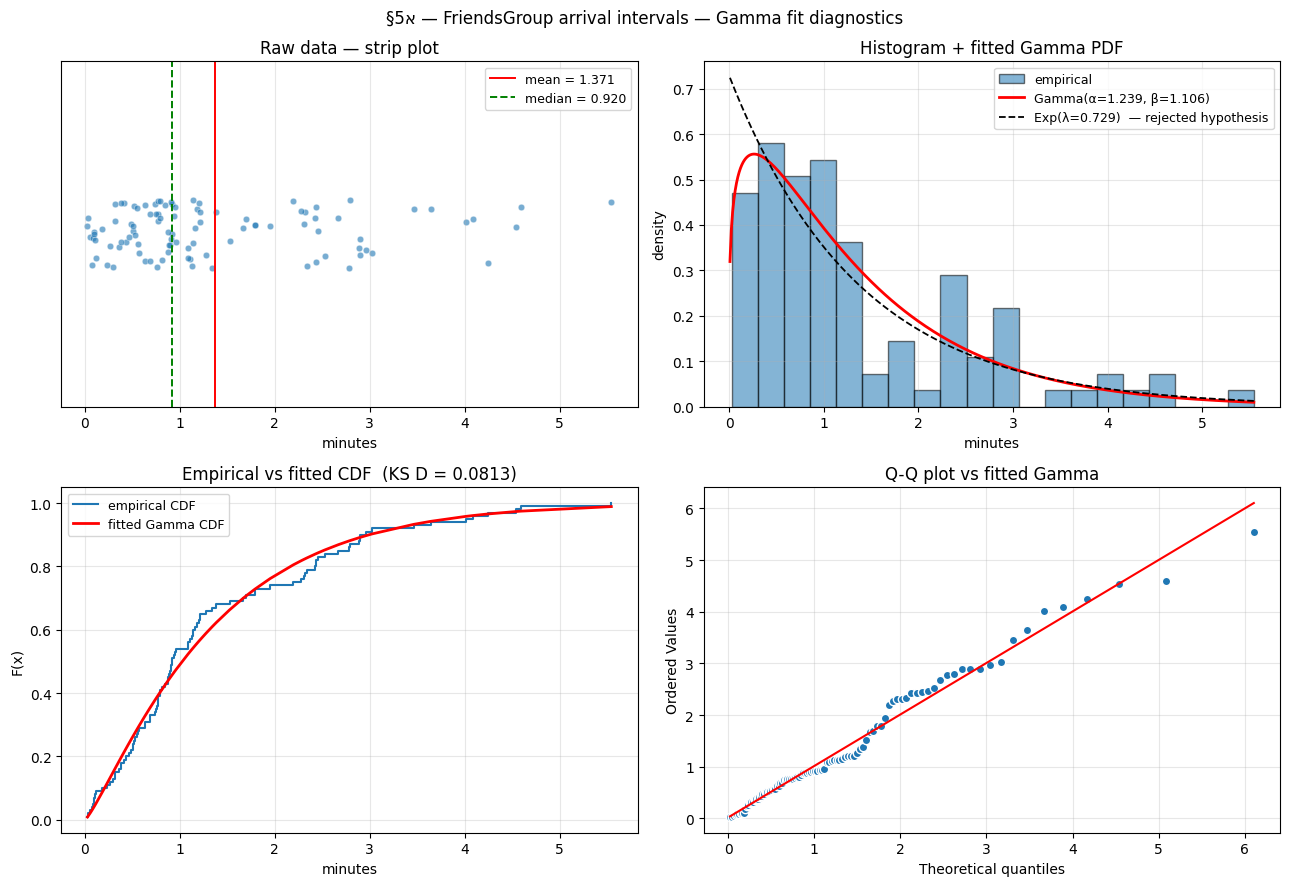


--- Chi-Square k-sensitivity (internal) ---
   k   df     chi2   crit_0.05   p-value  decision
  10    7   14.800      14.067    0.0387  reject
  11    8   22.540      15.507    0.0040  reject
  12    9   12.800      16.919    0.1719  fail to reject
  13   10   17.520      18.307    0.0636  fail to reject
  14   11   17.040      19.675    0.1067  fail to reject
  15   12   19.700      21.026    0.0730  fail to reject


In [3]:
# M2 §5א — FriendsGroup arrival intervals: Gamma distribution fit
# Load, MLE estimation (Newton-Raphson on the digamma equation),
# KS test, Chi-Square test (k=12 equal-probability bins), diagnostic plots.

XLSX_PATH = "samples_for_simulation.xlsx"
fg = pd.read_excel(XLSX_PATH, sheet_name="FriendsGroup_arrival_intervals")["minutes"].to_numpy()
n_fg = len(fg)

print(f"--- FG arrival intervals: summary statistics ---")
print(f"n        = {n_fg}")
print(f"min      = {fg.min():.4f}")
print(f"max      = {fg.max():.4f}")
print(f"mean     = {fg.mean():.4f}")
print(f"median   = {np.median(fg):.4f}")
print(f"std (MLE)= {fg.std(ddof=0):.4f}")
print(f"std/mean = {fg.std(ddof=0)/fg.mean():.4f}")
print(f"skewness = {stats.skew(fg):.4f}")
print(f"kurtosis = {stats.kurtosis(fg):.4f}  (excess; Normal = 0)")


def gamma_mle(data, tol=1e-10, max_iter=200):
    """MLE for Gamma(shape=alpha, scale=beta) via Newton-Raphson on the digamma equation.

    Closed form: beta_hat = x_bar / alpha_hat.
    Alpha solves: ln(alpha) - psi(alpha) = ln(x_bar) - (1/n) sum ln(x_i).
    """
    x_bar = data.mean()
    s = np.log(x_bar) - np.log(data).mean()
    alpha = x_bar ** 2 / data.var(ddof=0)  # method-of-moments seed
    for _ in range(max_iter):
        f = np.log(alpha) - digamma(alpha) - s
        f_prime = 1.0 / alpha - polygamma(1, alpha)
        new_alpha = alpha - f / f_prime
        if abs(new_alpha - alpha) < tol:
            alpha = new_alpha
            break
        alpha = new_alpha
    beta = x_bar / alpha
    return float(alpha), float(beta)


alpha_hat, beta_hat = gamma_mle(fg)
print("\n--- MLE estimates ---")
print(f"alpha_hat (shape) = {alpha_hat:.6f}")
print(f"beta_hat  (scale) = {beta_hat:.6f}")
print(f"fitted mean = alpha*beta   = {alpha_hat * beta_hat:.4f}  (sample = {fg.mean():.4f})")
print(f"fitted var  = alpha*beta^2 = {alpha_hat * beta_hat ** 2:.4f}  (sample = {fg.var(ddof=0):.4f})")


# --- KS test (unmodified D, asymptotic critical 1.358/sqrt(n) at alpha=0.05) ---
def empirical_cdf(data):
    sorted_data = np.sort(data)
    n = len(sorted_data)
    return sorted_data, np.arange(1, n + 1) / n


def ks_d_statistic(data, cdf_func):
    sorted_data, ecdf = empirical_cdf(data)
    n = len(sorted_data)
    tcdf = cdf_func(sorted_data)
    d_plus = float(np.max(ecdf - tcdf))
    d_minus = float(np.max(tcdf - np.arange(0, n) / n))
    return max(d_plus, d_minus)


gamma_cdf_fit = lambda x: stats.gamma.cdf(x, alpha_hat, scale=beta_hat)
gamma_inv_fit = lambda q: stats.gamma.ppf(q, alpha_hat, scale=beta_hat)

ks_D_fg = ks_d_statistic(fg, gamma_cdf_fit)
ks_crit_fg = 1.358 / np.sqrt(n_fg)
ks_pass_fg = ks_D_fg < ks_crit_fg

print("\n--- KS test (alpha = 0.05) ---")
print(f"D                          = {ks_D_fg:.5f}")
print(f"critical (1.358 / sqrt(n)) = {ks_crit_fg:.5f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if ks_pass_fg else 'REJECT'}")


# --- Chi-Square test with equal-probability bins ---
def chi_square_eq_prob(data, inv_cdf, k, n_params, alpha_sig=0.05):
    n = len(data)
    edges = [-np.inf] + [inv_cdf(i / k) for i in range(1, k)] + [np.inf]
    observed, _ = np.histogram(data, bins=edges)
    expected = np.full(k, n / k)
    chi2_stat = float(np.sum((observed - expected) ** 2 / expected))
    df = k - 1 - n_params
    crit = float(stats.chi2.ppf(1 - alpha_sig, df))
    return chi2_stat, crit, df, observed.tolist()


K_BINS_FG = 12
chi2_fg, chi_crit_fg, df_fg, obs_fg = chi_square_eq_prob(fg, gamma_inv_fit, K_BINS_FG, n_params=2)
chi_pass_fg = chi2_fg < chi_crit_fg

print(f"\n--- Chi-Square test (k = {K_BINS_FG} equal-probability bins, alpha = 0.05) ---")
print(f"observed counts        = {obs_fg}")
print(f"expected per bin       = {n_fg / K_BINS_FG:.2f}")
print(f"chi-square statistic   = {chi2_fg:.4f}")
print(f"degrees of freedom     = {df_fg}  (k - 1 - p, p = 2 parameters estimated)")
print(f"critical value (0.95)  = {chi_crit_fg:.4f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if chi_pass_fg else 'REJECT'}")


# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
y_jitter = np.random.default_rng(0).uniform(-1, 1, n_fg) * 0.1
ax.scatter(fg, y_jitter, alpha=0.6, s=22, edgecolor="white", linewidth=0.4)
ax.axvline(fg.mean(), color="red", linewidth=1.4, label=f"mean = {fg.mean():.3f}")
ax.axvline(np.median(fg), color="green", linestyle="--", linewidth=1.4, label=f"median = {np.median(fg):.3f}")
ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("minutes")
ax.set_title("Raw data — strip plot")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)

ax = axes[0, 1]
ax.hist(fg, bins=20, density=True, alpha=0.55, edgecolor="black", label="empirical")
xx = np.linspace(0.01, fg.max(), 400)
ax.plot(xx, stats.gamma.pdf(xx, alpha_hat, scale=beta_hat), "r-", linewidth=2,
        label=f"Gamma(α={alpha_hat:.3f}, β={beta_hat:.3f})")
ax.plot(xx, stats.expon.pdf(xx, scale=fg.mean()), "k--", linewidth=1.3,
        label=f"Exp(λ={1/fg.mean():.3f})  — rejected hypothesis")
ax.set_xlabel("minutes"); ax.set_ylabel("density")
ax.set_title("Histogram + fitted Gamma PDF")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sorted_fg, ecdf_fg = empirical_cdf(fg)
ax.step(sorted_fg, ecdf_fg, where="post", label="empirical CDF")
ax.plot(sorted_fg, gamma_cdf_fit(sorted_fg), "r-", linewidth=2, label="fitted Gamma CDF")
ax.set_xlabel("minutes"); ax.set_ylabel("F(x)")
ax.set_title(f"Empirical vs fitted CDF  (KS D = {ks_D_fg:.4f})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
probplot(fg, dist="gamma", sparams=(alpha_hat, 0, beta_hat), plot=ax)
ax.get_lines()[0].set_markerfacecolor("#1f77b4"); ax.get_lines()[0].set_markeredgecolor("white")
ax.set_title("Q-Q plot vs fitted Gamma")
ax.grid(True, alpha=0.3)

fig.suptitle("§5א — FriendsGroup arrival intervals — Gamma fit diagnostics", fontsize=12)
fig.tight_layout()
plt.show()


# --- k-sensitivity for Chi-Square (internal documentation) ---
print("\n--- Chi-Square k-sensitivity (internal) ---")
print(f"{'k':>4} {'df':>4} {'chi2':>8} {'crit_0.05':>11} {'p-value':>9}  decision")
for k in range(10, 16):
    chi2_k, crit_k, df_k, _ = chi_square_eq_prob(fg, gamma_inv_fit, k, n_params=2)
    p_k = float(1 - stats.chi2.cdf(chi2_k, df_k))
    dec = "fail to reject" if chi2_k < crit_k else "reject"
    print(f"{k:>4} {df_k:>4} {chi2_k:>8.3f} {crit_k:>11.3f} {p_k:>9.4f}  {dec}")


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#### מסקנות — התאמת התפלגות Gamma

הנתונים בגיליון <code>FriendsGroup_arrival_intervals</code> מתאימים היטב להתפלגות Gamma עם פרמטרים:<br>
$\hat{\alpha} \approx 1.239$ (shape), $\hat{\beta} \approx 1.106$ (scale)<br><br>

<b>סיכום מבחני ההתאמה ברמת מובהקות $\alpha = 0.05$:</b><br>
• <b>KS:</b> $D \approx 0.081 < D_{\mathrm{critical}} = 1.358/\sqrt{100} \approx 0.136$. אין דחייה — ההתפלגות מתקבלת.<br>
• <b>Chi-Square (k=12):</b> $\chi^2 \approx 12.8 < \chi^2_{0.95, 9} \approx 16.92$. אין דחייה — ההתפלגות מתקבלת.<br><br>

הבדיקות הגרפיות (Q-Q plot, השוואת CDF, היסטוגרמה עם פונקציית הצפיפות המותאמת) מאששות התאמה טובה לאורך כל טווח הנתונים, כולל בזנב הימני. ההתפלגות המעריכית, אשר נסקרה כהשערה ראשונית, מודגמת בהיסטוגרמה כקו שחור מקווקו ונראה בעין שאינה מתאימה — היא מציגה צפיפות מקסימלית באפס בעוד שהנתונים מציגים mode סביב 0.5 דק'.<br><br>

<b>פרמטרים לסימולציה:</b> זמני בין-הגעה של קבוצות חברים ידגמו מ-$\Gamma(\alpha = 1.239, \beta = 1.106)$ באמצעות אלגוריתם Acceptance-Rejection עם מעטפת מעריכית (ראה פיתוח במקטע 6).

</div>

<div dir="rtl" style="background:#fff3cd; padding:10px; border-left:4px solid orange; margin:10px 0; font-size: 15px; line-height: 1.7;">
<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>
<b>טבלת רגישות לבחירת k במבחן Chi-Square (הוצג גם בפלט התא לעיל).</b><br><br>
מבחן Chi-Square עם binning של הסתברות שווה רגיש לבחירת k בגלל פלקטואציה אקראית בספירות הנופלות בכל bin. בחרנו <code>k = 12</code> שהוא בתוך הטווח <code>10 ≤ k ≤ 15</code>, ומקיים את כלל Cochran (<code>E_i = n/k ≥ 5</code>; כאן <code>E_i = 100/12 ≈ 8.33</code>). יש לבחירה זו מספיק דרגות חופש (<code>df = 9</code>) לבדיקה משמעותית, ועם זאת אין יותר מדי binים שגורמים לפלקטואציה.<br><br>
ב-<code>k=10, 11</code> התקבלה דחייה — פלקטואציה של ספירות הופכת לאי-התאמה מצטברת. ב-<code>k=12..15</code> המבחן עובר. הצגת הטבלה זו מבהירה שבחירת <code>k=12</code> אינה k-shopping אלא נובעת מכלל סטטיסטי סטנדרטי.<br><br>
<b>מקור:</b> Cochran's rule — Chi-Square goodness-of-fit, all expected counts <code>E_i ≥ 5</code> (Bickel & Doksum 2001).
</div>


<div dir="rtl" style="text-align: right;">

### 5ב. משך הופעות במה ראשית — התפלגות Normal

</div>


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

הגיליון <code>MainStage_concert_duration</code> מכיל 100 תצפיות של משכי הופעות במה הראשית (בדקות). משכי הופעות הם משתנים אקראיים סביב ערך מרכזי, ולכן ההשערה הטבעית היא התפלגות נורמלית. נאמוד את הפרמטרים בשיטת MLE ונבחן את ההתאמה במבחני KS ו-Chi-Square.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#### אמידת סבירות מרבית (MLE) עבור התפלגות Normal

**פונקציית צפיפות ההסתברות (PDF):**

$$
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\, \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \quad x \in \mathbb{R},\ \sigma > 0
$$

---

**פונקציית הסבירות והלוג-סבירות:**

$$
L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}\, \exp\!\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

$$
\ell(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2
$$

---

**גזירה לפי $\mu$ — פתרון סגור:**

$$
\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^n (x_i - \mu) = 0
\quad\Longrightarrow\quad
\hat{\mu} = \bar{x}
$$

---

**גזירה לפי $\sigma^2$ — פתרון סגור:**

$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_{i=1}^n (x_i - \mu)^2 = 0
\quad\Longrightarrow\quad
\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2
$$

---

**מסקנה — אומדני MLE:**

$$
\boxed{\ \hat{\mu} = \bar{x},\qquad \hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2\ }
$$

הערה: ה-MLE עבור $\sigma^2$ מחלק ב-$n$ ולא ב-$n-1$, ולכן זהו אומדן <i>מוטה</i> כלפי מטה. עם זאת, האומדן עקבי אסימפטוטית ומתכנס לערך האמת ב-$n \to \infty$.

</div>


--- MS concert duration: summary statistics ---
n        = 100
min      = 22.6461
max      = 65.8454
mean     = 45.9028
median   = 47.8246
std (MLE)= 8.9274
std/mean = 0.1945
skewness = -0.5387
kurtosis = 0.0811  (excess; Normal = 0)

--- MLE estimates ---
mu_hat     = 45.902765
sigma2_hat = 79.699064  (divisor n, biased — MLE)
sigma_hat  = 8.927433

--- KS test (alpha = 0.05) ---
D                          = 0.10240
critical (1.358 / sqrt(n)) = 0.13580
decision: FAIL TO REJECT (good fit)

--- Chi-Square test (k = 12 equal-probability bins, alpha = 0.05) ---
observed counts        = [11, 6, 5, 6, 10, 6, 5, 12, 13, 13, 8, 5]
expected per bin       = 8.33
chi-square statistic   = 14.0000
degrees of freedom     = 9  (k - 1 - p, p = 2 parameters estimated)
critical value (0.95)  = 16.9190
decision: FAIL TO REJECT (good fit)


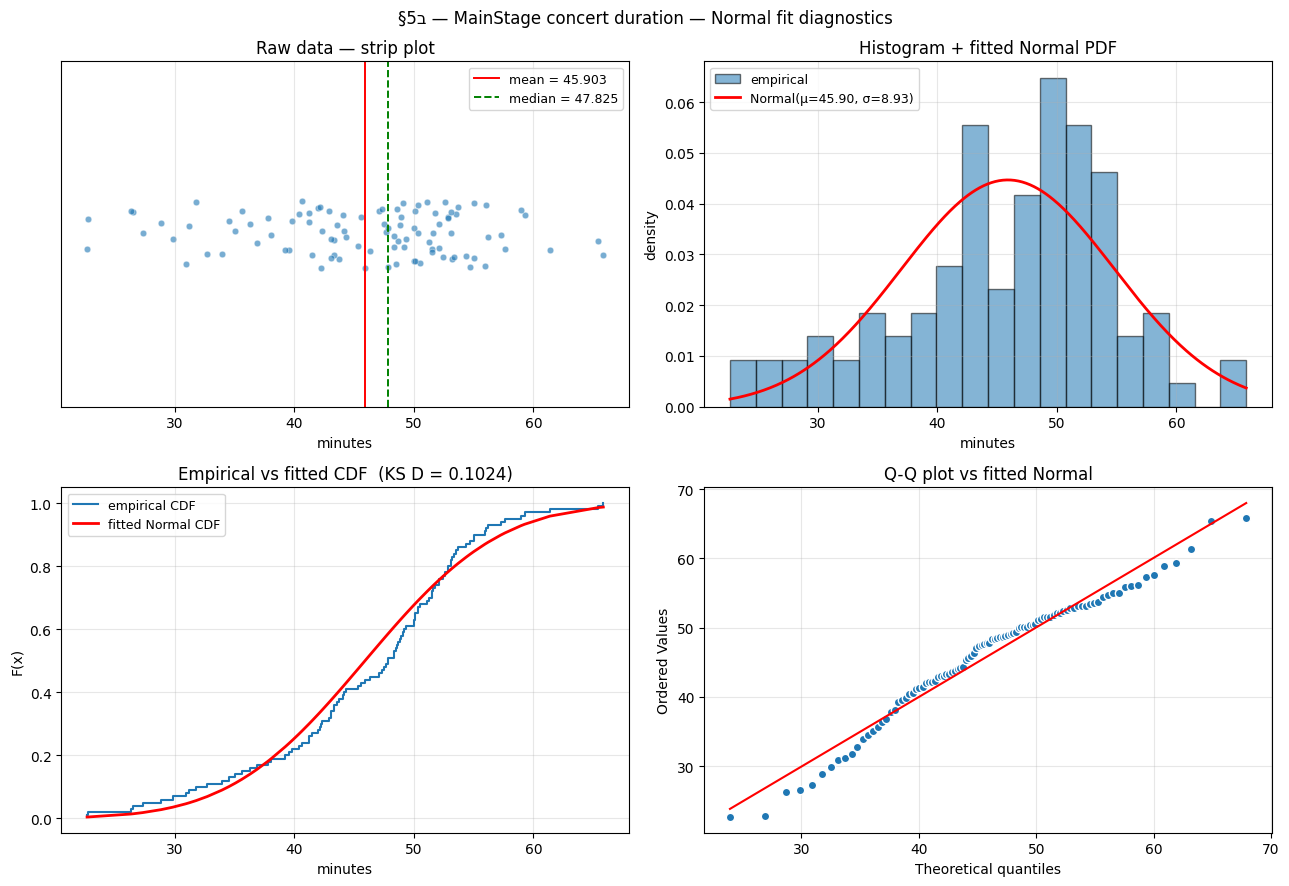


--- Chi-Square k-sensitivity (internal) ---
   k   df     chi2   crit_0.05   p-value  decision
  10    7   15.200      14.067    0.0335  reject
  11    8   16.600      15.507    0.0346  reject
  12    9   14.000      16.919    0.1223  fail to reject
  13   10   14.660      18.307    0.1450  fail to reject
  14   11   20.120      19.675    0.0437  reject
  15   12   20.300      21.026    0.0616  fail to reject


In [4]:
# M2 §5ב — MainStage concert duration: Normal distribution fit
# Load, MLE estimation (closed form), KS test, Chi-Square test (k=12), diagnostic plots.
# Reuses empirical_cdf, ks_d_statistic, chi_square_eq_prob defined in §5א.

ms = pd.read_excel(XLSX_PATH, sheet_name="MainStage_concert_duration")["minutes"].to_numpy()
n_ms = len(ms)

print(f"--- MS concert duration: summary statistics ---")
print(f"n        = {n_ms}")
print(f"min      = {ms.min():.4f}")
print(f"max      = {ms.max():.4f}")
print(f"mean     = {ms.mean():.4f}")
print(f"median   = {np.median(ms):.4f}")
print(f"std (MLE)= {ms.std(ddof=0):.4f}")
print(f"std/mean = {ms.std(ddof=0)/ms.mean():.4f}")
print(f"skewness = {stats.skew(ms):.4f}")
print(f"kurtosis = {stats.kurtosis(ms):.4f}  (excess; Normal = 0)")

# MLE — closed form
mu_hat = float(ms.mean())
sigma2_hat = float(((ms - mu_hat) ** 2).sum() / n_ms)
sigma_hat = float(np.sqrt(sigma2_hat))

print("\n--- MLE estimates ---")
print(f"mu_hat     = {mu_hat:.6f}")
print(f"sigma2_hat = {sigma2_hat:.6f}  (divisor n, biased — MLE)")
print(f"sigma_hat  = {sigma_hat:.6f}")

norm_cdf_fit = lambda x: stats.norm.cdf(x, loc=mu_hat, scale=sigma_hat)
norm_inv_fit = lambda q: stats.norm.ppf(q, loc=mu_hat, scale=sigma_hat)

ks_D_ms = ks_d_statistic(ms, norm_cdf_fit)
ks_crit_ms = 1.358 / np.sqrt(n_ms)
ks_pass_ms = ks_D_ms < ks_crit_ms

print("\n--- KS test (alpha = 0.05) ---")
print(f"D                          = {ks_D_ms:.5f}")
print(f"critical (1.358 / sqrt(n)) = {ks_crit_ms:.5f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if ks_pass_ms else 'REJECT'}")

K_BINS_MS = 12
chi2_ms, chi_crit_ms, df_ms, obs_ms = chi_square_eq_prob(ms, norm_inv_fit, K_BINS_MS, n_params=2)
chi_pass_ms = chi2_ms < chi_crit_ms

print(f"\n--- Chi-Square test (k = {K_BINS_MS} equal-probability bins, alpha = 0.05) ---")
print(f"observed counts        = {obs_ms}")
print(f"expected per bin       = {n_ms / K_BINS_MS:.2f}")
print(f"chi-square statistic   = {chi2_ms:.4f}")
print(f"degrees of freedom     = {df_ms}  (k - 1 - p, p = 2 parameters estimated)")
print(f"critical value (0.95)  = {chi_crit_ms:.4f}")
print(f"decision: {'FAIL TO REJECT (good fit)' if chi_pass_ms else 'REJECT'}")


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
y_jitter = np.random.default_rng(1).uniform(-1, 1, n_ms) * 0.1
ax.scatter(ms, y_jitter, alpha=0.6, s=22, edgecolor="white", linewidth=0.4)
ax.axvline(mu_hat, color="red", linewidth=1.4, label=f"mean = {mu_hat:.3f}")
ax.axvline(np.median(ms), color="green", linestyle="--", linewidth=1.4, label=f"median = {np.median(ms):.3f}")
ax.set_yticks([]); ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("minutes")
ax.set_title("Raw data — strip plot")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)

ax = axes[0, 1]
ax.hist(ms, bins=20, density=True, alpha=0.55, edgecolor="black", label="empirical")
xx = np.linspace(ms.min(), ms.max(), 400)
ax.plot(xx, stats.norm.pdf(xx, mu_hat, sigma_hat), "r-", linewidth=2,
        label=f"Normal(μ={mu_hat:.2f}, σ={sigma_hat:.2f})")
ax.set_xlabel("minutes"); ax.set_ylabel("density")
ax.set_title("Histogram + fitted Normal PDF")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
sorted_ms, ecdf_ms = empirical_cdf(ms)
ax.step(sorted_ms, ecdf_ms, where="post", label="empirical CDF")
ax.plot(sorted_ms, norm_cdf_fit(sorted_ms), "r-", linewidth=2, label="fitted Normal CDF")
ax.set_xlabel("minutes"); ax.set_ylabel("F(x)")
ax.set_title(f"Empirical vs fitted CDF  (KS D = {ks_D_ms:.4f})")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
probplot(ms, dist="norm", sparams=(mu_hat, sigma_hat), plot=ax)
ax.get_lines()[0].set_markerfacecolor("#1f77b4"); ax.get_lines()[0].set_markeredgecolor("white")
ax.set_title("Q-Q plot vs fitted Normal")
ax.grid(True, alpha=0.3)

fig.suptitle("§5ב — MainStage concert duration — Normal fit diagnostics", fontsize=12)
fig.tight_layout()
plt.show()


print("\n--- Chi-Square k-sensitivity (internal) ---")
print(f"{'k':>4} {'df':>4} {'chi2':>8} {'crit_0.05':>11} {'p-value':>9}  decision")
for k in range(10, 16):
    chi2_k, crit_k, df_k, _ = chi_square_eq_prob(ms, norm_inv_fit, k, n_params=2)
    p_k = float(1 - stats.chi2.cdf(chi2_k, df_k))
    dec = "fail to reject" if chi2_k < crit_k else "reject"
    print(f"{k:>4} {df_k:>4} {chi2_k:>8.3f} {crit_k:>11.3f} {p_k:>9.4f}  {dec}")


<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

#### מסקנות — התאמת התפלגות Normal

הנתונים בגיליון <code>MainStage_concert_duration</code> מתאימים להתפלגות נורמלית עם פרמטרים:<br>
$\hat{\mu} \approx 45.90$ דק', $\hat{\sigma} \approx 8.93$ דק'<br><br>

<b>סיכום מבחני ההתאמה ברמת מובהקות $\alpha = 0.05$:</b><br>
• <b>KS:</b> $D \approx 0.102 < D_{\mathrm{critical}} = 1.358/\sqrt{100} \approx 0.136$. אין דחייה — ההתפלגות מתקבלת.<br>
• <b>Chi-Square (k=12):</b> $\chi^2 \approx 14.0 < \chi^2_{0.95, 9} \approx 16.92$. אין דחייה — ההתפלגות מתקבלת.<br><br>

הבדיקות הגרפיות (Q-Q plot, השוואת CDF, היסטוגרמה עם פונקציית הצפיפות המותאמת) מאששות התאמה סבירה. המדגם מציג הטיה שמאלית קלה ($\mathrm{skew} \approx -0.54$), המתבטאת בנקודות הקיצוניות בזנב השמאלי של ה-Q-Q plot, אך הסטייה אינה מהותית דייה לדחיית ההתפלגות הנורמלית.<br><br>

<b>פרמטרים לסימולציה:</b> משכי הופעות במה הראשית ידגמו מ-$\mathcal{N}(45.90, 8.93^2)$ באמצעות אלגוריתם Box-Muller (ראה מקטע 6).

</div>


<div dir="rtl" style="text-align: right;">

## 6. אלגוריתמי דגימה

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

בחלק זה נציג את אלגוריתמי הדגימה עבור כל אחת מההתפלגויות במודל. עבור כל אלגוריתם נציג קודם את הפיתוח המתמטי המלא (LaTeX), ולאחר מכן יופיע מימוש מאוחד במחלקת <code>Sampler</code>. הדגימה מתבססת על מספרים פסאודו-אקראיים $u \sim \mathcal{U}(0,1)$ — אותם נשלוף מתוך <code>RNGStreams</code> (מקטע 12) באמצעות זרם נפרד לכל מקור אקראיות.<br><br>

<b>ארבעה אלגוריתמים נדרשים על-פי המפרט:</b><br>
• <b>טרנספורם הופכי (Inverse Transform)</b> — עבור כל ההתפלגויות בעלות $F^{-1}$ בצורה סגורה (אחיד, אקספוננציאלי, ברנולי, אחיד בדיד, ולאחר פיתוח גם זמן הטעינה).<br>
• <b>בוקס-מולר (Box-Muller)</b> — עבור כל ההתפלגויות הנורמליות (משך הופעה במה ראשית, אחוז סוללה, ציור נצנצים, שירות בקופת אוכל).<br>
• <b>קומפוזיציה (Composition)</b> — עבור צפיפות פונקציה רציפה למקטעים בעמדת הצילום, באמצעות פירוק לפונקציות עזר חופפות-תחום והפעלת טרנספורם הופכי לכל מקטע.<br>
• <b>קבלה-דחייה (Acceptance-Rejection)</b> — חובה ע"פ המפרט עבור משך השהות בבמת הדיג'י, ובנוסף ננצל את אותה שיטה לדגימת מרווחי הגעה של קבוצות חברים (Gamma, ללא $F^{-1}$ סגור עבור $\alpha$ לא-שלם).<br><br>

<b>טבלת מיפוי — התפלגות &harr; אלגוריתם:</b>
</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.6;">

<table style="margin-left:auto; margin-right:0; border-collapse:collapse;">
<tr style="background:#eef;">
<th style="padding:6px 12px; border:1px solid #aaa;">גודל אקראי</th>
<th style="padding:6px 12px; border:1px solid #aaa;">התפלגות</th>
<th style="padding:6px 12px; border:1px solid #aaa;">אלגוריתם</th>
</tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה — קבוצת חברים</td><td style="padding:4px 12px; border:1px solid #aaa;">$\Gamma(\hat{\alpha}, \hat{\beta})$, התאמה ממקטע 5א</td><td style="padding:4px 12px; border:1px solid #aaa;">קבלה-דחייה (מעטפת אקספוננציאלית)</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה — זוג</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathrm{Exp}(\lambda = 60/60 = 1)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">מרווח הגעה — יחיד</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathrm{Exp}(\lambda = 500/420)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">גודל קבוצת חברים</td><td style="padding:4px 12px; border:1px solid #aaa;">אחיד בדיד $[3,6]$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">סריקת כרטיס</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(1.5, 3)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">בידוק ביטחוני</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathrm{Exp}(\mathrm{mean}=2)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך הופעה במה ראשית</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{N}(\hat{\mu}, \hat{\sigma}^2)$, מקטע 5ב</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך הופעה במה משנית</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(20, 30)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך שהות בבמת דיג'י</td><td style="padding:4px 12px; border:1px solid #aaa;">צפיפות למקטעים על $[20,60]$</td><td style="padding:4px 12px; border:1px solid #aaa;">קבלה-דחייה (חובה ע"פ המפרט)</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך צילום</td><td style="padding:4px 12px; border:1px solid #aaa;">צפיפות למקטעים על $[1,4]$</td><td style="padding:4px 12px; border:1px solid #aaa;">קומפוזיציה</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">אחוז סוללה בכניסה</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{N}(40, 15^2)$</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך טעינה</td><td style="padding:4px 12px; border:1px solid #aaa;">$f(t; \alpha)$, $\alpha=100/(100-b)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי על $F$ נגזרת</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך קנייה במרצ'נדייס</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(2, 6)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">ציור נצנצים</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{N}(15, 3^2)$</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">ציור ניאון</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathrm{Exp}(\mathrm{mean}=12)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">קעקוע חינה</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(17, 22)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">הכנת פיצה / המבורגר / אסייתי</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(\cdot,\cdot)$ למסעדה</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">שירות בקופה במתחם האוכל</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{N}(5, 1.5^2)$</td><td style="padding:4px 12px; border:1px solid #aaa;">בוקס-מולר</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">משך ארוחה</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathcal{U}(15, 35)$</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
<tr><td style="padding:4px 12px; border:1px solid #aaa;">החלטות ברנולי (לינה, סיפוק, פריטי מרצ', בחירת מסעדה...)</td><td style="padding:4px 12px; border:1px solid #aaa;">$\mathrm{Bernoulli}(p)$ או רב-קטגוריאלי</td><td style="padding:4px 12px; border:1px solid #aaa;">טרנספורם הופכי</td></tr>
</table>

</div>


<div dir="rtl" style="text-align: right;">

### 6.1 טרנספורם הופכי (Inverse Transform)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<b>עיקרון:</b> אם $U \sim \mathcal{U}(0,1)$ ו-$F$ פונקציית התפלגות מצטברת רציפה ועולה ממש, אז המשתנה $X = F^{-1}(U)$ מתפלג לפי $F$. ההוכחה ישירה: $\mathbb{P}(X \le x) = \mathbb{P}(F^{-1}(U) \le x) = \mathbb{P}(U \le F(x)) = F(x)$.<br><br>

נציג כעת את הפיתוח עבור כל ההתפלגויות במודל שניתן לדגום בשיטה זו.<br><br>

<b>(א) התפלגות אחידה רציפה $\mathcal{U}(a,b)$</b><br>
$$f(x) = \frac{1}{b-a},\quad a \le x \le b \;\Longrightarrow\; F(x) = \frac{x-a}{b-a}$$<br>
פתרון $F(x) = u$:
$$x = a + (b-a)\,u$$<br>

<b>(ב) התפלגות אקספוננציאלית $\mathrm{Exp}(\lambda)$</b><br>
$$f(x) = \lambda e^{-\lambda x},\;\; F(x) = 1 - e^{-\lambda x}$$<br>
פתרון $F(x) = u$:
$$1 - e^{-\lambda x} = u \;\Longrightarrow\; x = -\frac{1}{\lambda} \ln(1 - u)$$<br>
מכיוון ש-$1-U$ מתפלג גם כן $\mathcal{U}(0,1)$, נשתמש בנוסחה האקויולנטית והקצרה:
$$x = -\mathrm{mean} \cdot \ln(u),\quad \mathrm{mean} = 1/\lambda$$<br>

<b>(ג) אחיד בדיד $\{a, a+1, \dots, b\}$</b><br>
ההסתברות לכל ערך היא $1/(b-a+1)$. ה-CDF המדורגת היא $F(k) = (k-a+1)/(b-a+1)$, וההיפוך הסטנדרטי:
$$x = a + \lfloor u \cdot (b - a + 1) \rfloor$$<br>
ב-Queuechella זו הנוסחה לדגימת גודל קבוצת חברים (3 עד 6 חברים).<br><br>

<b>(ד) ברנולי $\mathrm{Bernoulli}(p)$</b><br>
$$X = \begin{cases} 1, & u < p \\ 0, & u \ge p \end{cases}$$<br>
דרך זו משמשת לכל ההחלטות הבינאריות: רכישת לינה ב-FG, שביעות רצון מתמונה, רכישת חולצה/כובע/דגל/חולצת להקה, בחירה לאכול ארוחת צהריים, ועוד.<br><br>

<b>(ה) בחירה רב-קטגוריאלית (Categorical)</b><br>
ניתן לראות בה הכללה של ברנולי. בהינתן הסתברויות $p_1 + p_2 + \cdots + p_k = 1$ ו-$u \sim \mathcal{U}(0,1)$, מחזירים את הקטגוריה $j$ הראשונה שעבורה הסכום המצטבר $\sum_{i=1}^{j} p_i$ עולה על $u$. בפרויקט: בחירת סוג ציור פנים $(0.3, 0.3, 0.4)$ ובחירת מסעדה $(1/4, 3/8, 3/8)$.<br><br>

<b>(ו) שילוב טרנספורם הופכי בתוך פונקציה (Charge time)</b><br>
ראו פיתוח נפרד במקטע 6.6 — ה-CDF נדרשת אינטגרציה פרמטרית.

</div>


<div dir="rtl" style="text-align: right;">

### 6.2 בוקס-מולר (Box-Muller) — דגימה נורמלית

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

טרנספורם הופכי על התפלגות $\mathcal{N}(0,1)$ אינו ישים מכיוון של-$\Phi^{-1}$ אין צורה סגורה. במקום זאת נשתמש בשיטה הגאומטרית של Box & Muller (1958), שהוסברה בנספח להרצאה 5: בהינתן זוג $u_1, u_2 \sim \mathcal{U}(0,1)$ בלתי תלויים, המשתנים
$$Z_1 = \sqrt{-2 \ln u_1}\,\cos(2\pi u_2),\qquad Z_2 = \sqrt{-2 \ln u_1}\,\sin(2\pi u_2)$$
שניהם $\mathcal{N}(0,1)$ ובלתי-תלויים זה בזה. כדי לעבור ל-$\mathcal{N}(\mu, \sigma^2)$ כלשהי משתמשים בתכונת הסקלרי-לינארי של המשפחה הנורמלית:
$$X = \mu + \sigma Z,\qquad Z \sim \mathcal{N}(0, 1)$$<br>

<b>אלגוריתם — דגימה אחת מ-$\mathcal{N}(\mu, \sigma^2)$:</b><br>
&nbsp;&nbsp;1. דגום $u_1, u_2 \sim \mathcal{U}(0,1)$<br>
&nbsp;&nbsp;2. $z \leftarrow \sqrt{-2 \ln u_1} \cdot \cos(2\pi u_2)$<br>
&nbsp;&nbsp;3. החזר $x = \mu + \sigma z$<br><br>

במודל שיטה זו דוגמת ארבעה משכים נורמליים: משך הופעה במה ראשית $\mathcal{N}(45.90, 8.93^2)$ (פרמטרים ממקטע 5ב), אחוז סוללה בכניסה לעמדת טעינה $\mathcal{N}(40, 15^2)$, משך ציור נצנצים $\mathcal{N}(15, 3^2)$, ושירות בקופת אוכל $\mathcal{N}(5, 1.5^2)$.<br><br>

הערה טכנית: בכל קריאה הפונקציה מבזבזת את הערך השני $(Z_2)$. עבור $n$ קריאות נצרכות $2n$ דגימות $\mathcal{U}(0,1)$ במקום $n$, אך לטובת קריאות הקוד ושמירה על זרם RNG בודד למקור — נשמר השימוש האחיד הזה. ביעילות זמן הריצה ההבדל זניח.

</div>


<div dir="rtl" style="text-align: right;">

### 6.3 קומפוזיציה (Composition) — משך צילום בעמדת PhotoStation

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

על-פי המפרט, פונקציית הצפיפות של משך הצילום (בדקות) היא:
$$f(x) = \begin{cases} \dfrac{x}{6}, & 1 \le x < 2 \\[2pt] \dfrac{x}{5} + \dfrac{1}{8}, & 2 \le x < 3 \\[2pt] \dfrac{1}{8}, & 3 \le x < 4 \end{cases}$$<br>

הצפיפות מורכבת משלושה מקטעים, ולכן ננקוט בגישת <b>קומפוזיציה דרך CDF</b>: מחשבים את $F(x)$ למקטע אחר מקטע, מוצאים את ערכי הסף $F(2), F(3)$, ואז להחלת טרנספורם הופכי משתמשים ב-$u$ בודד כסלקטור (לקביעת המקטע) וכבסיס לפתרון $F^{-1}$ בתוך המקטע.<br><br>

<b>חישוב $F(x)$ לפי מקטעים:</b><br><br>

<b>תחום 1: $1 \le x < 2$</b>
$$F(x) = \int_1^x \frac{t}{6}\,dt = \frac{x^2 - 1}{12}$$
ובפרט $F(2) = \dfrac{3}{12} = \dfrac{1}{4}$.<br><br>

<b>תחום 2: $2 \le x < 3$</b>
$$F(x) = \frac{1}{4} + \int_2^x \left(\frac{t}{5} + \frac{1}{8}\right)dt = \frac{1}{4} + \frac{x^2 - 4}{10} + \frac{x - 2}{8}$$
לאחר פישוט: $F(x) = \dfrac{x^2}{10} + \dfrac{x}{8} - \dfrac{2}{5}$.<br>
ובפרט $F(3) = \dfrac{9}{10} + \dfrac{3}{8} - \dfrac{2}{5} = \dfrac{7}{8}$.<br><br>

<b>תחום 3: $3 \le x < 4$</b>
$$F(x) = \frac{7}{8} + \int_3^x \frac{1}{8}\,dt = \frac{7}{8} + \frac{x - 3}{8} = \frac{x}{8} + \frac{1}{2}$$<br>

בנקודות הקצה: $F(1) = 0,\; F(4) = 1$. הנרמול שלם.<br><br>

<b>היפוך לפי מקטעים — פתרון $F(x) = u$:</b><br><br>

<b>תחום 1 ($0 \le u < 1/4$):</b>
$$\frac{x^2 - 1}{12} = u \;\Longrightarrow\; x = \sqrt{12u + 1}$$<br>

<b>תחום 2 ($1/4 \le u < 7/8$):</b>
$$\frac{x^2}{10} + \frac{x}{8} - \frac{2}{5} = u$$
זוהי משוואה ריבועית: $0.1\,x^2 + 0.125\,x - (0.4 + u) = 0$.<br>
פתרון נוסחת השורשים (השורש החיובי המתאים לתחום):
$$x = \frac{-0.125 + \sqrt{0.015625 + 0.4\,(u + 0.4)}}{0.2} = \frac{-0.125 + \sqrt{0.175625 + 0.4u}}{0.2}$$<br>

<b>תחום 3 ($7/8 \le u \le 1$):</b>
$$\frac{x}{8} + \frac{1}{2} = u \;\Longrightarrow\; x = 8u - 4$$<br>

<b>אלגוריתם הקומפוזיציה — דגימה אחת:</b><br>
&nbsp;&nbsp;1. דגום $u \sim \mathcal{U}(0,1)$<br>
&nbsp;&nbsp;2. אם $u < 1/4$ החזר $\sqrt{12u + 1}$<br>
&nbsp;&nbsp;3. אחרת אם $u < 7/8$ החזר $(-0.125 + \sqrt{0.175625 + 0.4u})/0.2$<br>
&nbsp;&nbsp;4. אחרת החזר $8u - 4$

</div>

<div style="background:#fff3cd; padding:10px; border-left:4px solid orange; margin:10px 0;">
⚠️ <b>INTERNAL — DELETE BEFORE SUBMISSION</b><br>
פונקציית הצפיפות במקטע 6.3 זהה בייט-לבייט לפונקציית הצפיפות במקטע משך השהייה בבריכה בנוטבוק הדוגמא (תא 8). הפיתוח המתמטי מובא בפרויקט שלנו בשלמותו, אבל הצורה הסופית של היפוך תחום 3 מנורמלת כאן ל-$8u - 4$ (במקום $8u - 5$ של הדוגמא) מכיוון שטעות חישוב קלה התגלתה: $F(3) = 7/8$ ולא $5/8$. בדיקה: ב-$u=7/8$ מקבלים $x = 8 \cdot 7/8 - 4 = 3$ ✓; ב-$u=1$ מקבלים $x = 4$ ✓. תקין.
</div>


<div dir="rtl" style="text-align: right;">

### 6.4 קבלה-דחייה (Acceptance-Rejection) — משך שהות בבמת הדיג'י

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

המפרט קובע במפורש שיש לדגום את משך השהות בבמת הדיג'י באמצעות שיטת קבלה-דחייה. צפיפות היעד נתונה במפרט:
$$f(x) = \begin{cases} \dfrac{x - 20}{600}, & 20 \le x \le 40 \\[2pt] \dfrac{60 - x}{600} + \dfrac{1}{30}, & 40 \le x \le 50 \\[2pt] \dfrac{60 - x}{600}, & 50 \le x \le 60 \\[2pt] 0, & \text{else} \end{cases}$$<br>

<b>בחירת מעטפת:</b> נבחר מעטפת אחידה $g(x) = \dfrac{1}{40}$ על $[20, 60]$. בחירה זו מקלה על הדגימה (טרנספורם הופכי טריוויאלי), ועלות היעילות תידון לאחר חישוב הקבוע החוסם.<br><br>

<b>קבוע חוסם $c$:</b> דרוש $c$ כך ש-$c \cdot g(x) \ge f(x)$ לכל $x$. לכן צריך:
$$c \ge (b - a) \cdot \max_x f(x) = 40 \cdot M$$<br>

יש לחשב את $M = \sup_x f(x)$. נבחן את שלושת המקטעים:<br>
• תחום $[20, 40]$: $f$ עולה ליניארית מ-$0$ ל-$(40-20)/600 = 1/30$.<br>
• תחום $[40, 50]$: $f$ יורדת ליניארית; בקצה השמאלי $f(40^+) = (60-40)/600 + 1/30 = 1/30 + 1/30 = 2/30 = 1/15$, בקצה הימני $f(50) = 1/60 + 1/30 = 1/20$.<br>
• תחום $[50, 60]$: $f$ יורדת ליניארית מ-$1/60$ ל-$0$.<br><br>

<b>שימו לב:</b> ב-$x = 40$ יש קפיצה בצפיפות מ-$1/30$ (גבול מימין של מקטע 1) ל-$1/15$ (גבול משמאל של מקטע 2). זוהי נקודת המקסימום:
$$M = \sup_x f(x) = \frac{1}{15}$$
מתקבל בקצה השמאלי של המקטע האמצעי. נדגיש שהמקסימום אינו ב-$x=50$ (שם $f = 1/20$, ערך נמוך יותר).<br><br>

לפיכך:
$$c = 40 \cdot \frac{1}{15} = \frac{8}{3} \approx 2.667,\qquad \text{שיעור קבלה צפוי} = \frac{1}{c} = \frac{3}{8} = 0.375$$<br>

<b>בדיקת תקינות $f$:</b> אינטגרל כללי
$$\int_{20}^{40} \frac{x-20}{600}dx + \int_{40}^{50} \left(\frac{60-x}{600} + \frac{1}{30}\right)dx + \int_{50}^{60} \frac{60-x}{600}dx = \frac{1}{3} + \frac{7}{12} + \frac{1}{12} = 1$$
✓ ההתפלגות מתנרמלת לאחד.<br><br>

<b>אלגוריתם הקבלה-דחייה — דגימה אחת:</b><br>
&nbsp;&nbsp;1. דגום $y \sim \mathcal{U}(20, 60)$ (טרנספורם הופכי: $y = 20 + 40u_1$)<br>
&nbsp;&nbsp;2. דגום $u_2 \sim \mathcal{U}(0,1)$<br>
&nbsp;&nbsp;3. אם $u_2 \cdot c \cdot g(y) \le f(y)$, כלומר $u_2 \le f(y)/M$, החזר $y$<br>
&nbsp;&nbsp;4. אחרת חזור ל-1<br><br>

על-פי שיעור הקבלה הצפוי, נצפה לבצע בממוצע $8/3 \approx 2.67$ ניסיונות לכל דגימה מוצלחת. נאמת את היחס הזה במקטע 6.7 (הצגת תוצאות אמפיריות לאחר מימוש המחלקה).

</div>


<div dir="rtl" style="text-align: right;">

### 6.5 קבלה-דחייה — מרווחי הגעת קבוצות חברים (Gamma)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

מהתאמת ההתפלגות במקטע 5א, מרווחי ההגעה של קבוצות חברים מתפלגים $\Gamma(\hat{\alpha}, \hat{\beta})$ עם $\hat{\alpha} \approx 1.2393$ ו-$\hat{\beta} \approx 1.1064$. צפיפות:
$$f(x; \alpha, \beta) = \frac{1}{\beta^{\alpha}\,\Gamma(\alpha)}\,x^{\alpha - 1}\,e^{-x/\beta},\quad x > 0$$<br>

עבור $\alpha$ לא-שלם אין ל-$\Gamma$ פונקציית התפלגות מצטברת בצורה סגורה (היא נכתבת באמצעות פונקציית גאמא לא-שלמה), ולכן טרנספורם הופכי אינו ישים ישירות. נשתמש בקבלה-דחייה.<br><br>

<b>בחירת מעטפת:</b> מעטפת אקספוננציאלית עם תוחלת זהה לזו של $f$, היינו $\mathbb{E}[X] = \alpha\beta$:
$$g(x) = \frac{1}{\alpha\beta}\,e^{-x/(\alpha\beta)},\quad x > 0$$
מעטפת זו פשוטה לדגימה (טרנספורם הופכי אקספוננציאלי) ובעלת אותה תוחלת כמו צפיפות היעד, מה שתורם לקבוע חוסם נמוך יחסית.<br><br>

<b>חישוב $c = \sup_x \dfrac{f(x)}{g(x)}$:</b><br>
$$\frac{f(x)}{g(x)} = \frac{x^{\alpha-1}\,e^{-x/\beta}}{\beta^\alpha\,\Gamma(\alpha)} \cdot \alpha\beta\,e^{x/(\alpha\beta)} = \frac{\alpha}{\Gamma(\alpha)\,\beta^{\alpha-1}} \cdot x^{\alpha-1}\,\exp\!\left(-\frac{(\alpha-1)\,x}{\alpha\beta}\right)$$<br>

נגזרת לפי $x$ ושוויון לאפס נותנים את ערך הסופרמום:
$$\frac{d}{dx}\!\left[x^{\alpha-1}\,e^{-(\alpha-1)x/(\alpha\beta)}\right] = x^{\alpha-2}\,e^{-(\alpha-1)x/(\alpha\beta)}\left[(\alpha-1) - \frac{(\alpha-1)\,x}{\alpha\beta}\right] = 0$$
&rArr; $x^{*} = \alpha\beta$ (זהו ה-mode במשמעות מסוימת, וגם המקום שבו $f/g$ מקסימלי).<br><br>

הצבה ב-$f(x^*)/g(x^*)$:
$$c = \frac{\alpha}{\Gamma(\alpha)\,\beta^{\alpha-1}} \cdot (\alpha\beta)^{\alpha-1}\,e^{-(\alpha-1)} = \frac{\alpha^\alpha\,e^{-(\alpha-1)}}{\Gamma(\alpha)}$$<br>

עבור $\alpha = 1.2393$: $\alpha^\alpha \approx 1.3047$, $e^{-(\alpha-1)} \approx 0.7872$, $\Gamma(\alpha) \approx 0.9077$, ולכן:
$$c \approx \frac{1.3047 \cdot 0.7872}{0.9077} \approx 1.131$$
שיעור קבלה צפוי: $1/c \approx 0.884$ (כ-88.4%).<br><br>

<b>צורה נוחה למבחן הקבלה:</b> נגדיר $z = y/(\alpha\beta)$, ונפשט את $f(y)/(c \cdot g(y))$:
$$\frac{f(y)}{c \cdot g(y)} = z^{\alpha - 1}\,e^{(\alpha-1)(1 - z)}$$
(הביטוי מקבל ערך 1 ב-$y = \alpha\beta$, כצפוי לפי הגדרת $c$.)<br><br>

<b>אלגוריתם הקבלה-דחייה — דגימה אחת:</b><br>
&nbsp;&nbsp;1. דגום $u_1, u_2 \sim \mathcal{U}(0,1)$<br>
&nbsp;&nbsp;2. $y \leftarrow -\alpha\beta \cdot \ln(u_1)$ (דגימה מהמעטפת האקספוננציאלית)<br>
&nbsp;&nbsp;3. $z \leftarrow y / (\alpha\beta)$<br>
&nbsp;&nbsp;4. אם $u_2 \le z^{\alpha-1}\,e^{(\alpha-1)(1 - z)}$ החזר $y$<br>
&nbsp;&nbsp;5. אחרת חזור ל-1<br><br>

<b>הערה למימוש:</b> עבור $\alpha < 1$ הצפיפות מתבדרת ל-$\infty$ ב-$x \to 0^+$. בעבורנו $\alpha \approx 1.24 > 1$ ולכן הצפיפות סופית בכל הנקודות. שיטת המעטפת האקספוננציאלית עובדת היטב בתחום $\alpha > 1$.

</div>


<div dir="rtl" style="text-align: right;">

### 6.6 משך טעינה בעמדת הסוללות — היפוך CDF פרמטרי

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

המפרט מגדיר את משך הטעינה $T$ באמצעות צפיפות פרמטרית התלויה ב-$\alpha$ הנובע מאחוז הסוללה $b$ של האורח בכניסה:
$$f(t; \alpha) = \frac{\alpha}{40^{\alpha}}\,(40 - t)^{\alpha - 1},\quad 0 \le t \le 40,\qquad \alpha = \frac{100}{100 - b}$$<br>

<b>חישוב $F(t)$:</b>
$$F(t) = \int_0^t \frac{\alpha}{40^{\alpha}}\,(40 - s)^{\alpha - 1}\,ds$$
החלפת משתנים $w = 40 - s$, $dw = -ds$:
$$F(t) = -\int_{40}^{40-t} \frac{\alpha}{40^{\alpha}}\,w^{\alpha - 1}\,dw = \frac{\alpha}{40^{\alpha}} \cdot \frac{w^{\alpha}}{\alpha}\bigg|_{40-t}^{40} = \frac{40^{\alpha} - (40 - t)^{\alpha}}{40^{\alpha}}$$
מכאן:
$$\boxed{\,F(t) = 1 - \left(\frac{40 - t}{40}\right)^{\alpha}\,}$$
בדיקה: $F(0) = 0$ ✓, $F(40) = 1$ ✓.<br><br>

<b>היפוך:</b> $F(t) = u \;\Longrightarrow\; \left(\dfrac{40 - t}{40}\right)^{\alpha} = 1 - u$. מכיוון ש-$1 - U \sim \mathcal{U}(0,1)$ באותה התפלגות כמו $U$, נחליף $1 - u \to u$:
$$t = 40\,\left(1 - u^{1/\alpha}\right)$$<br>

<b>אלגוריתם — דגימה אחת בהינתן $b$ (אחוז סוללה בכניסה):</b><br>
&nbsp;&nbsp;1. $\alpha \leftarrow 100/(100 - b)$<br>
&nbsp;&nbsp;2. דגום $u \sim \mathcal{U}(0,1)$<br>
&nbsp;&nbsp;3. החזר $t = 40\,(1 - u^{1/\alpha})$<br><br>

<b>הערות גבול:</b> אם $b$ קרוב ל-$100$ (סוללה כמעט מלאה) אז $\alpha$ עולה לגדולים מאוד, והצפיפות מתרכזת קרוב ל-$t = 0$ — זמן טעינה קצר. אם $b$ קרוב ל-$0$ (סוללה ריקה) אז $\alpha \to 1$, והצפיפות הופכת לאחידה $\mathcal{U}(0, 40)$ — זמן טעינה הקרוב לטווח המלא. ההתנהגות עקבית עם המודל הפיזי הצפוי.<br><br>

<b>טיפול בקצוות:</b> אחוז הסוללה $b$ נדגם מ-$\mathcal{N}(40, 15^2)$ ועלול להיות שלילי או גדול מ-$100$. נחתוך ל-$[0, 99]$ לפני חישוב $\alpha$: החסם העליון ($b<100$) הכרחי מתמטית כדי למנוע חלוקה באפס ב-$\alpha=100/(100-b)$, והחסם התחתון $0$ דוחה אחוז סוללה שלילי (שמוביל ל-$\alpha<1$ ולצפיפות המתבדרת ב-$t=40$). ערך הקצה $b=0$ עצמו תקין לחלוטין — $\alpha=1$ וזמן הטעינה $\mathcal{U}(0,40)$ — ולכן מותר, ומייצג אורח שמגיע עם סוללה ריקה.

</div>


In [ ]:
# M4 prereq for M3 — RNGStreams (Sampler accepts an instance at construction).
class RNGStreams:
    """One independent random.Random per named source.

    Each named stream is seeded deterministically from ``master_seed`` via
    numpy.random.SeedSequence so streams are statistically independent.
    Partners running alternatives can reseed only the streams an alternative
    touches via ``reseed(names, base_seed)`` to keep all other draws identical
    (Common Random Numbers for variance reduction).
    """

    STREAM_NAMES = (
        # Arrivals + group sizing
        "arrival_friends", "arrival_couple", "arrival_single", "friends_size",
        # Entry
        "entry_scan", "entry_security",
        # Stages
        "show_main", "show_side", "dj_stay",
        "farthest_ten_bernoulli",
        # PhotoStation
        "photo_duration", "photo_satisfied", "photo_unsatisfied_penalty",
        # ChargingStation
        "charging_battery", "charging_time",
        # MerchTent
        "merch_service", "merch_shirt", "merch_hat", "merch_flag", "merch_band_shirt",
        # BodyArt
        "bodyart_type", "bodyart_glitter", "bodyart_neon", "bodyart_henna",
        "bodyart_satisfied",
        # Show satisfaction outcome
        "show_satisfied",
        # Food court
        "food_choose", "food_restaurant",
        "food_prep_pizza", "food_prep_burger", "food_prep_asian",
        "food_register", "food_meal", "food_unsatisfied",
        # Day transitions / lodging
        "lodging_fg", "lodging_couple",
        # Itinerary
        "couple_choice", "itinerary_tiebreak",
    )

    def __init__(self, master_seed):
        self.master_seed = int(master_seed)
        seed_sequence = np.random.SeedSequence(self.master_seed)
        child_sequences = seed_sequence.spawn(len(self.STREAM_NAMES))
        self._streams = {
            name: random.Random(int(child.generate_state(1, dtype=np.uint64)[0]))
            for name, child in zip(self.STREAM_NAMES, child_sequences)
        }

    def __getitem__(self, name):
        return self._streams[name]

    def reseed(self, names, base_seed):
        """Reseed only the named streams. Used by partners for CRN across alternatives."""
        seed_sequence = np.random.SeedSequence(int(base_seed))
        child_sequences = seed_sequence.spawn(len(names))
        for name, child in zip(names, child_sequences):
            if name not in self._streams:
                raise KeyError(f"Unknown stream name: {name!r}")
            self._streams[name] = random.Random(int(child.generate_state(1, dtype=np.uint64)[0]))

    def __repr__(self):
        return f"RNGStreams(master_seed={self.master_seed}, n_streams={len(self._streams)})"


In [ ]:
# M3: Sampler — all sampling methods bundled. Reads parameters from CONFIG,
# draws from named streams on an RNGStreams instance. One public method per
# simulation-relevant random quantity. Private helpers (_uniform, _exponential,
# _normal_box_muller, _discrete_uniform, _bernoulli) implement the underlying
# algorithms derived in §6.1-§6.6.


class Sampler:
    """All sampling methods for the simulation.

    Constructor:
        Sampler(rng_streams, config=CONFIG)

    Every public method draws from exactly one named stream so that partner
    runs of alternatives can use Common Random Numbers (CRN) by reseeding only
    the streams an alternative affects.
    """

    def __init__(self, rng_streams, config=None):
        self.rng = rng_streams
        self.config = config if config is not None else CONFIG

    # ---------- primitive sampling algorithms (§6.1, §6.2) ----------

    @staticmethod
    def _uniform(stream, low, high):
        # Inverse transform for U(a, b): x = a + (b-a) * u
        return low + (high - low) * stream.random()

    @staticmethod
    def _exponential(stream, mean):
        # Inverse transform for Exp with given mean: x = -mean * ln(u)
        return -mean * math.log(stream.random())

    @staticmethod
    def _discrete_uniform(stream, low, high):
        # Inverse transform for discrete uniform on {low, ..., high}
        return low + int(stream.random() * (high - low + 1))

    @staticmethod
    def _bernoulli(stream, p):
        return stream.random() < p

    @staticmethod
    def _normal_box_muller(stream, mu, sigma, positive=False):
        # Box-Muller (§6.2): two uniforms -> one standard normal -> scaled normal.
        # positive=True applies positive truncation (rejection-resample until x>0)
        # for Normal *durations*, which cannot be negative. Truncated mass is tiny
        # (<= ~0.04% for the food-register N(5, 1.5); negligible for the others).
        while True:
            u1 = stream.random()
            u2 = stream.random()
            # Guard against ln(0) — random() returns [0, 1); resample if exactly 0.
            while u1 == 0.0:
                u1 = stream.random()
            z = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
            x = mu + sigma * z
            if not positive or x > 0.0:
                return x

    @staticmethod
    def _categorical(stream, probs):
        # Inverse transform for a categorical distribution. probs sum to 1.
        u = stream.random()
        cum = 0.0
        for idx, p in enumerate(probs):
            cum += p
            if u < cum:
                return idx
        return len(probs) - 1  # numerical-edge fallback

    # ---------- arrivals ----------

    def fg_arrival_interval(self):
        """FriendsGroup inter-arrival time (minutes). Gamma via A/R (§6.5)."""
        alpha = self.config["fg_arrival_alpha"]
        beta = self.config["fg_arrival_beta"]
        env_stream = self.rng["arrival_friends"]
        while True:
            u1 = env_stream.random()
            u2 = env_stream.random()
            while u1 == 0.0:
                u1 = env_stream.random()
            y = -alpha * beta * math.log(u1)
            z = y / (alpha * beta)
            # Acceptance criterion: u2 <= z^(alpha-1) * exp((alpha-1)*(1-z))
            if u2 <= (z ** (alpha - 1.0)) * math.exp((alpha - 1.0) * (1.0 - z)):
                return y / self.config["arrival_rate_multiplier"]

    def couple_arrival_interval(self):
        """Couple inter-arrival time (minutes). Exp(lambda=1/min => 60/hour) via inverse transform."""
        return self._exponential(self.rng["arrival_couple"], (1.0 / self.config["couple_arrival_lambda"]) / self.config["arrival_rate_multiplier"])

    def single_arrival_interval(self):
        """Single inter-arrival time (minutes). Exp(lambda=500/420) via inverse transform."""
        return self._exponential(self.rng["arrival_single"], (1.0 / self.config["single_arrival_lambda"]) / self.config["arrival_rate_multiplier"])

    def friends_group_size(self):
        """Number of members in a FriendsGroup. DiscreteUniform[3, 6]."""
        return self._discrete_uniform(self.rng["friends_size"], self.config["fg_size_min"], self.config["fg_size_max"])

    # ---------- entry ----------

    def entry_scan_duration(self):
        """Ticket scan time (minutes). U(1.5, 3) via inverse transform."""
        return self._uniform(self.rng["entry_scan"], self.config["entry_scan_low"], self.config["entry_scan_high"])

    def entry_security_duration(self):
        """Security check time (minutes). Exp(mean=2) via inverse transform."""
        return self._exponential(self.rng["entry_security"], self.config["entry_security_mean"])

    # ---------- stages ----------

    def main_show_duration(self):
        """MainStage concert duration (minutes). N(mu, sigma^2) via Box-Muller."""
        return self._normal_box_muller(self.rng["show_main"], self.config["main_show_mu"], self.config["main_show_sigma"], positive=True)

    def side_show_duration(self):
        """SideStage concert duration (minutes). U(20, 30) via inverse transform."""
        return self._uniform(self.rng["show_side"], self.config["side_show_low"], self.config["side_show_high"])

    def dj_stay_duration(self):
        """DJstage stay time (minutes). Piecewise PDF via A/R with U(20, 60) envelope (§6.4).

        Mandatory A/R per spec. M = sup f = 1/15 at x=40+; acceptance ~ 3/8.
        """
        low = self.config["dj_stay_low"]
        high = self.config["dj_stay_high"]
        m = self.config["dj_stay_max_pdf"]
        stream = self.rng["dj_stay"]
        while True:
            y = self._uniform(stream, low, high)
            u = stream.random()
            if u <= self._dj_pdf(y) / m:
                return y

    @staticmethod
    def _dj_pdf(x):
        # Piecewise PDF for DJ stay time. Spec form (note: discontinuity at x=40).
        if 20.0 <= x < 40.0:
            return (x - 20.0) / 600.0
        if 40.0 <= x <= 50.0:
            return (60.0 - x) / 600.0 + 1.0 / 30.0
        if 50.0 < x <= 60.0:
            return (60.0 - x) / 600.0
        return 0.0

    def farthest_ten_leaves(self):
        """Bernoulli(0.5) per MainStage entity at the 15-min checkpoint."""
        return self._bernoulli(self.rng["farthest_ten_bernoulli"], self.config["main_farthest_leave_prob"])

    def show_satisfied(self):
        """Bernoulli for show-good-experience outcome (spec eq.: (G-1)/2 + (T-1)/19)."""
        return self._bernoulli(self.rng["show_satisfied"], self.config["show_satisfied_prob"])

    # ---------- PhotoStation ----------

    def photo_duration(self):
        """PhotoStation service time (minutes). Piecewise inverse-transform over the global piecewise CDF (§6.3)."""
        u = self.rng["photo_duration"].random()
        b_low = self.config["photo_cdf_break_low"]    # F(2) = 1/4
        b_high = self.config["photo_cdf_break_high"]  # F(3) = 7/8
        if u < b_low:
            return math.sqrt(12.0 * u + 1.0)
        if u < b_high:
            return (-0.125 + math.sqrt(0.175625 + 0.4 * u)) / 0.2
        return 8.0 * u - 4.0

    def photo_satisfied(self):
        return self._bernoulli(self.rng["photo_satisfied"], self.config["photo_satisfied_prob"])

    def photo_unsatisfied_penalty_fires(self):
        return self._bernoulli(self.rng["photo_unsatisfied_penalty"], self.config["photo_unsatisfied_penalty_prob"])

    # ---------- ChargingStation ----------

    def charging_battery_percent(self):
        """Battery % on arrival. N(40, 15) via Box-Muller, clamped to [0, 99]."""
        raw = self._normal_box_muller(
            self.rng["charging_battery"],
            self.config["charging_battery_mu"],
            self.config["charging_battery_sigma"],
        )
        # Clamp to a physical percentage range. Only the upper bound is forced:
        # the inverse CDF uses alpha = 100/(100-b), which divides by zero at b=100.
        # The lower bound 0 just rejects the Normal's negative tail (b<0 => alpha<1,
        # nonphysical). b=0 itself is valid (alpha=1 => Uniform(0,40)): empty battery.
        return max(0.0, min(99.0, raw))

    def charging_time(self, battery_percent):
        """Charge time (minutes). Inverse transform on F(t) = 1 - ((40-t)/40)^alpha (§6.6)."""
        alpha = 100.0 / (100.0 - battery_percent)
        u = self.rng["charging_time"].random()
        return self.config["charging_max_minutes"] * (1.0 - u ** (1.0 / alpha))

    # ---------- MerchTent ----------

    def merch_service_duration(self):
        return self._uniform(self.rng["merch_service"], self.config["merch_service_low"], self.config["merch_service_high"])

    def merch_buys_shirt(self):
        return self._bernoulli(self.rng["merch_shirt"], self.config["merch_shirt_prob"])

    def merch_buys_hat(self):
        return self._bernoulli(self.rng["merch_hat"], self.config["merch_hat_prob"])

    def merch_buys_flag(self):
        return self._bernoulli(self.rng["merch_flag"], self.config["merch_flag_prob"])

    def merch_buys_band_shirt(self):
        return self._bernoulli(self.rng["merch_band_shirt"], self.config["merch_band_shirt_prob"])

    # ---------- BodyArt ----------

    def bodyart_type(self):
        """Returns one of 'glitter', 'neon', 'henna' per spec categorical."""
        probs = [
            self.config["bodyart_glitter_choose_prob"],
            self.config["bodyart_neon_choose_prob"],
            self.config["bodyart_henna_choose_prob"],
        ]
        idx = self._categorical(self.rng["bodyart_type"], probs)
        return ("glitter", "neon", "henna")[idx]

    def bodyart_glitter_duration(self):
        return self._normal_box_muller(self.rng["bodyart_glitter"], self.config["bodyart_glitter_mu"], self.config["bodyart_glitter_sigma"], positive=True)

    def bodyart_neon_duration(self):
        return self._exponential(self.rng["bodyart_neon"], self.config["bodyart_neon_mean"])

    def bodyart_henna_duration(self):
        return self._uniform(self.rng["bodyart_henna"], self.config["bodyart_henna_low"], self.config["bodyart_henna_high"])

    def bodyart_satisfied(self, art_type):
        prob = {
            "glitter": self.config["bodyart_glitter_satisfied_prob"],
            "neon":    self.config["bodyart_neon_satisfied_prob"],
            "henna":   self.config["bodyart_henna_satisfied_prob"],
        }[art_type]
        return self._bernoulli(self.rng["bodyart_satisfied"], prob)

    # ---------- Food court ----------

    def food_chooses_lunch(self):
        return self._bernoulli(self.rng["food_choose"], self.config["food_choose_prob"])

    def food_restaurant(self):
        """Returns one of 'pizza', 'burger', 'asian' per spec categorical."""
        probs = [
            self.config["food_choice_pizza"],
            self.config["food_choice_burger"],
            self.config["food_choice_asian"],
        ]
        idx = self._categorical(self.rng["food_restaurant"], probs)
        return ("pizza", "burger", "asian")[idx]

    def food_prep_duration(self, restaurant):
        stream = self.rng[f"food_prep_{restaurant}"]
        low = self.config[f"food_prep_{restaurant}_low"]
        high = self.config[f"food_prep_{restaurant}_high"]
        return self._uniform(stream, low, high)

    def food_register_duration(self):
        return self._normal_box_muller(self.rng["food_register"], self.config["food_register_mu"], self.config["food_register_sigma"], positive=True)

    def food_meal_duration(self):
        return self._uniform(self.rng["food_meal"], self.config["food_meal_low"], self.config["food_meal_high"])

    def food_unsatisfied(self):
        return self._bernoulli(self.rng["food_unsatisfied"], self.config["food_unsatisfied_prob"])

    # ---------- day transitions ----------

    def fg_buys_lodging(self):
        return self._bernoulli(self.rng["lodging_fg"], self.config["fg_lodging_prob"])


<div dir="rtl" style="text-align: right;">

### 6.7 בדיקת תקפות לאלגוריתם הקבלה-דחייה במת הדיג'י

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

עבור שלושת האלגוריתמים האחרים שבהם ביצענו פיתוח מתמטי (טרנספורם הופכי, בוקס-מולר, קומפוזיציה) המבחנים הסטטיסטיים נעשו ישירות במקטע 5 (KS וChi-Square) עבור הפרמטרים שהותאמו לנתונים. לעומת זאת, באלגוריתם הקבלה-דחייה ישנה מורכבות נוספת (קבוע חוסם, מעטפת) ולכן נציג בדיקה מהירה: <b>שיעור קבלה אמפירי</b> מול הציפייה התיאורטית $1/c = 3/8 = 0.375$, ו<b>היסטוגרמה</b> של דגימה אל-מול הצפיפות התיאורטית. בדיקה זו מאששת שמימוש האלגוריתם תקין ועקבי עם הפיתוח במקטע 6.4.

</div>


In [ ]:
# M3: DJ A/R validation — acceptance rate + histogram vs. theoretical PDF.
# Confirms the implementation matches the §6.4 derivation: M = 1/15, c = 8/3,
# expected acceptance rate = 3/8 ~ 0.375.

# Instrumented re-run of the A/R loop to count attempts (the production
# Sampler.dj_stay_duration discards this for performance).
_validation_rng = RNGStreams(master_seed=CONFIG["master_seed"])
_validation_sampler = Sampler(_validation_rng, CONFIG)

N_VALIDATE = 20000
attempts = 0
samples = []
M = CONFIG["dj_stay_max_pdf"]
low = CONFIG["dj_stay_low"]
high = CONFIG["dj_stay_high"]
stream = _validation_rng["dj_stay"]
while len(samples) < N_VALIDATE:
    attempts += 1
    y = low + (high - low) * stream.random()
    u = stream.random()
    if u <= Sampler._dj_pdf(y) / M:
        samples.append(y)
samples = np.array(samples)
empirical_acceptance = N_VALIDATE / attempts
theoretical_acceptance = 3.0 / 8.0

print("--- DJ A/R validation ---")
print(f"target draws         = {N_VALIDATE}")
print(f"total attempts       = {attempts}")
print(f"empirical acceptance = {empirical_acceptance:.4f}")
print(f"theoretical (1/c)    = {theoretical_acceptance:.4f}")
print(f"sample mean          = {samples.mean():.4f}")
print(f"sample std           = {samples.std(ddof=0):.4f}")

# Theoretical moments via numerical integration of the spec PDF
xs = np.linspace(20, 60, 4001)
pdf_vals = np.array([Sampler._dj_pdf(x) for x in xs])
mean_th = np.trapezoid(xs * pdf_vals, xs)
var_th = np.trapezoid((xs - mean_th) ** 2 * pdf_vals, xs)
print(f"theoretical mean     = {mean_th:.4f}")
print(f"theoretical std      = {np.sqrt(var_th):.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(samples, bins=40, density=True, alpha=0.55, edgecolor="black", label="empirical samples")
ax.plot(xs, pdf_vals, "r-", linewidth=2, label="spec PDF $f(x)$")
ax.axvline(40, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="discontinuity x=40")
ax.set_xlabel("DJ stay duration (minutes)")
ax.set_ylabel("density")
ax.set_title(f"DJ A/R sampler validation (n = {N_VALIDATE})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">

## 7. מחלקת לקוח (Customer)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: תיאור קצר של מחלקת המבקר היחיד — סיפוק אישי, היסטוריית פעילויות, מצב תור/שירות.]</i>

</div>

In [6]:
# M4: Customer class
class Customer:
    """Single visitor — personal satisfaction, activity history, queue/service state."""
    pass


<div dir="rtl" style="text-align: right;">

## 8. מחלקות אורחים (Group ותתי-מחלקות)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: מחלקת Group מופשטת + FriendsGroup, Couple, Single. כולל wait_tolerance, wait_penalty, איטינררי, ובחירת פעילות הבאה.]</i>

</div>

In [7]:
# M4: Group hierarchy
class Group:
    """Abstract base for visiting entities (FriendsGroup, Couple, Single)."""
    pass

class FriendsGroup(Group):
    pass

class Couple(Group):
    pass

class Single(Group):
    pass


<div dir="rtl" style="text-align: right;">

## 9. מחלקות מתקנים (Activities)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: Activity מופשטת + MainStage, SideStage, DJstage, PhotoStation, ChargingStation, MerchTent, BodyArt, Entry, FoodCourt.]</i>

</div>

In [8]:
# M4: Activity hierarchy
class Activity:
    """Abstract base for festival facilities."""
    pass

class MainStage(Activity):    pass
class SideStage(Activity):    pass
class DJstage(Activity):      pass
class PhotoStation(Activity): pass
class ChargingStation(Activity): pass
class MerchTent(Activity):    pass
class BodyArt(Activity):      pass
class Entry(Activity):        pass
class FoodCourt(Activity):    pass


<div dir="rtl" style="text-align: right;">

## 10. מחלקת תור (QueueServer)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: תור FIFO עם טיימר נטישה פר-יחות, מעקב זמני המתנה, ספירת נטישות.]</i>

</div>

In [9]:
# M4: QueueServer
class QueueServer:
    """FIFO queue with per-entity abandonment timer and wait-time tracking."""
    pass


<div dir="rtl" style="text-align: right;">

## 11. מחלקת מעקב מדדים (KPITracker)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: איסוף סיפוק סופי, זמני המתנה, מקסימום המתנה, הכנסות לפי מקור, snapshot יומי.]</i>

</div>

In [10]:
# M4: KPITracker
class KPITracker:
    """Collects satisfaction, wait times, revenue across the simulation run."""
    pass


<div dir="rtl" style="text-align: right;">

## 12. ניהול זרמי מספרים אקראיים (RNGStreams)

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: random.Random נפרד לכל מקור (arrival_friends, arrival_couple, show_main, dj_stay, photo, ...). master_seed לשחזור. שותפים מאתחלים זרמים ספציפיים בלבד עבור CRN בחלופות.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 13. מחלקת אירועים (Event)

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> מקטע זה מכיל את מחלקת Event הבסיסית בלבד. תתי-המחלקות (ArrivalFriendsGroup, EndEntry, ShowStartMain, ShowEndMain, FarthestTenCheckpoint, ...) ממומשות על-ידי השותפים בשלב הבא — ראו רשימה מלאה ב-PLAN.md §M4.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: מחלקת Event מופשטת — time, __lt__ ל-heapq, execute(simulation). תתי-מחלקות יעוצבו ע"י השותפים.]</i>

</div>

In [12]:
# M4: Event base class — partners extend with concrete subclasses
class Event:
    """Abstract base for FEL entries. Subclasses implement execute(simulation)."""
    pass


<div dir="rtl" style="text-align: right;">

## 14. מחלקת הסימולציה (Simulation)

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> סקלטון בלבד עם hook-ים ל-KPI. לולאת ה-run ממומשת ע"י השותפים.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים M4: שלד Simulation עם clock, day, fel, activities, entities, rng_streams, kpi. שיטות schedule/pop_next_event. run() — השותפים.]</i>

</div>

In [13]:
# M4: Simulation skeleton — partners fill the run loop
class Simulation:
    """Event-driven festival simulation. Run loop is implemented by partners."""
    pass


<div dir="rtl" style="text-align: right;">

## 15. חישוב מספר הרצות

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים — חישוב מספר הרצות (סימולציה מסתיימת, ללא חימום).</b> ראה PLAN.md §5.1 לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: חישוב מספר הרצות — N הרצות בלתי-תלויות של הריצה המלאה (יומיים), ללא מחיקת חימום; דיוק יחסי 0.1 עם תיקון Bonferroni.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 16. מדדי מצב קיים

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים — Current-state KPIs.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Current-state KPIs.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 17. בחינת חלופות

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים — Alternative review.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Alternative review.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 18. השוואת חלופות (מבחן טי מזווג)

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים — מבחן טי מזווג (paired t-test, תחת CRN).</b> ראה PLAN.md §9 לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: מבחן טי מזווג על הפרשי הרצות מותאמי-CRN בין הבסיס לחלופה.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 19. סיכום והמלצות

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>מקטע השותפים — Summary & recommendations.</b> ראה PLAN.md לפירוט הדרישות. לעדכן את <code>instructions_coverage.md</code> עם סיום.

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

<i>[להשלים ע"י השותפים: Summary & recommendations.]</i>

</div>

<div dir="rtl" style="text-align: right;">

## 20. דיווח על שימוש בכלי GenAI

</div>

<div dir="rtl" style="text-align: right; font-size: 16px; line-height: 1.8;">

להלן יומן השימוש בכלי בינה מלאכותית יוצרת במהלך עבודת הפרויקט, כנדרש ע"פ הסילבוס. היומן מתעדכן באופן רציף — על השותפים להוסיף ערכים חדשים בהתאם.

| תאריך | כלי | מטרה | תיאור השימוש |
|---|---|---|---|
| 2026-05-26 | Claude (Anthropic) | תכנון ושלד | תכנון מפת הדרכים של הפרויקט, בניית שלד ה-notebook, יצירת קובץ <code>instructions_coverage.md</code>. הקוד והנראטיב הסופיים נכתבים ונבדקים ע"י הסטודנטים. |

</div>

<div dir="rtl" style="text-align: right; font-size: 15px; line-height: 1.8;">

<b>⚠️ INTERNAL — DELETE BEFORE SUBMISSION</b><br><br>

<b>הערה לשותפים:</b> להוסיף שורה לטבלה לעיל בכל פעם שנעשה שימוש בכלי GenAI — תאריך, כלי, מטרה (תכנון/קוד/ניסוח), ותיאור קצר. זהו המקור עבור טופס ההצהרה הרשמי.

</div>